# Algorithms of bluntly.ph — documented and simulated

**Capstone defense material.** Every formula in this notebook is imported from the
running backend, not retyped. Where a chart shows a curve, that curve was produced by
calling the same function the API calls.

- **Code under test:** `backend/app/` (imported live — see the provenance table below)
- **Existing simulation harness reused:** `backend/sim/` (four vote-influx scenarios)
- **Governing decisions:** `docs/adr/003`, `004`, `009`, `011`, `012`, `013`
- **Companion documents:** `docs/RANKING_SIMULATION.md`, `docs/BACKEND_CAPSTONE_PAPER.md`

### What this notebook is careful about

1. **No hand-copied formulas.** Functions are imported. Line citations are produced by
   `inspect.getsourcelines`, so they cannot drift from the code.
2. **Honest about what is wired.** Several pure functions in `ranking.py` are unit-tested
   but not yet called from any request path. Those are marked **NOT WIRED** and the
   notebook says so rather than implying the platform runs them today.
3. **Scope.** Seller trust ratings have been **deleted** from this codebase by owner decision
   (commits `cf7afbc` / `8936dda`); they are not documented here. *Product* trust — a different,
   surviving feature — is covered in Part 3.

### Contents

| Part | Algorithms |
|---|---|
| 1 | Wilson score interval, exponential recency decay, time-decayed Wilson, velocity detection, reciprocity/collusion, publication gate, phase transition |
| 2 | Reputation score, trust-stage ladder, gate vote weight |
| 3 | Product trust rating, low-trust visibility threshold |
| 4 | 40/30/30 commission split, tiered split, contract gate, Honesty Fund distribution, payout scheduling |
| 5 | Argon2id password KDF, fixed-window rate limiting, OTP brute-force resistance, PII retention schedule |
| 6 | AI critique stub heuristic, request screening, duplicate-content trigram similarity, username allocation |
| 7 | Coverage ledger — what could not be simulated, and why |

## 0 — Setup and provenance

The setup cell locates the repository root by anchor file, puts `backend/` on `sys.path`,
and imports the live modules. Nothing is stubbed.

In [1]:
from __future__ import annotations

import inspect
import math
import random
import subprocess
import sys
import time
from dataclasses import dataclass
from decimal import ROUND_FLOOR, Decimal
from pathlib import Path

# --- Locate the repository root by anchor, so this runs from any working directory.
def _find_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "backend" / "app" / "services" / "ranking.py").exists():
            return candidate
    raise RuntimeError("repository root not found from %s" % start)

REPO = _find_root(Path.cwd().resolve())
BACKEND = REPO / "backend"
if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))

ASSETS = REPO / "docs" / "assets" / "notebooks"
ASSETS.mkdir(parents=True, exist_ok=True)

print("repository :", REPO)
print("python     :", sys.version.split()[0])
try:
    sha = subprocess.run(["git", "-C", str(REPO), "rev-parse", "--short", "HEAD"],
                         capture_output=True, text=True, timeout=30).stdout.strip()
    print("git HEAD   :", sha or "(unavailable)")
except Exception as exc:                     # noqa: BLE001 - provenance only
    print("git HEAD   : (unavailable:", exc, ")")

repository : C:\Users\Blutnly.ph\Documents\GitHub\bluntly.ph
python     : 3.12.5
git HEAD   : 2b1ff47


In [2]:
# --- Live imports from the backend under test -------------------------------
from app.core import constants as C
from app.core.constants import (
    ACCOUNT_MATURATION_DAYS,
    HONESTY_FUND_SHARE,
    PAYOUT_MINIMUM_PHP,
    PLATFORM_SHARE,
    REVIEWER_SHARE,
    honesty_price_multiplier,
)
from app.services import ai_critique, earnings, pii, ranking, trust, username
from app.services.ai_critique import StubProvider, heuristic_validate
from app.services.earnings import (
    MAX_REVIEWER_SHARE_BPS,
    split_commission,
    split_commission_tiered,
)
from app.services.pii import due_actions, hash_ip, retention_deadlines
from app.services.ranking import (
    COLLUSION_MIN_VOTERS,
    COLLUSION_THRESHOLD,
    DECAY_HALF_LIFE_DAYS,
    GATE_MIN_STAGE2_VOTERS,
    GATE_WILSON_LB,
    RECIPROCITY_MIN_SHARED,
    RECIPROCITY_THRESHOLD,
    SEEDING_TRANSITION_REVIEWERS,
    VELOCITY_THRESHOLD,
    VELOCITY_WINDOW_SECONDS,
    WILSON_Z_95,
    decay_factor,
    gate_passes,
    is_post_seeding,
    reciprocity_flag,
    time_decayed_wilson,
    velocity_exceeded,
    wilson_lower_bound,
)
from app.services.trust import (
    BEST_ANSWER_CAP,
    BEST_ANSWER_COEFF,
    STAGE_MULTIPLIER,
    STRIKE_PENALTY,
    VOLUME_CAP,
    VOLUME_COEFF,
    W_HELPFULNESS,
    determine_stage,
    gate_vote_weight,
    honesty_score,
    reputation_score,
)
from app.services.username import allocate_username, is_valid_username, slugify_username

# The existing simulation harness — reused, not reimplemented.
from sim import scenarios as S

print("imports OK — %d ranking constants, %d trust constants" % (
    len([n for n in dir(ranking) if n.isupper()]),
    len([n for n in dir(trust) if n.isupper()]),
))

imports OK — 11 ranking constants, 8 trust constants


In [3]:
# --- Provenance table: file:line derived from the objects themselves ---------
def cite(obj) -> str:
    # `path:line` of a live object, relative to the repo root. Never hand-typed.
    src_file = Path(inspect.getsourcefile(obj)).resolve()
    _, line = inspect.getsourcelines(obj)
    return "%s:%d" % (src_file.relative_to(REPO).as_posix(), line)


CATALOGUE = [
    ("Wilson score lower bound",        wilson_lower_bound),
    ("Exponential recency decay",       decay_factor),
    ("Time-decayed Wilson",             time_decayed_wilson),
    ("Velocity (surge) detection",      velocity_exceeded),
    ("Reciprocity / collusion signal",  reciprocity_flag),
    ("Publication gate",                gate_passes),
    ("Seeding phase transition",        is_post_seeding),
    ("Reputation score",                reputation_score),
    ("Trust-stage ladder",              determine_stage),
    ("Gate vote weight",                gate_vote_weight),
    ("Honesty Score",                   honesty_score),
    ("Honesty price multiplier",        honesty_price_multiplier),
    ("Commission split 40/30/30",       split_commission),
    ("Tiered commission split",         split_commission_tiered),
    ("PII retention deadlines",         retention_deadlines),
    ("PII due-action resolver",         due_actions),
    ("Salted IP hash",                  hash_ip),
    ("AI critique stub scoring",        StubProvider.critique),
    ("Request screening heuristic",     heuristic_validate),
    ("Username slugification",          slugify_username),
    ("Username allocation",             allocate_username),
]

print("%-34s %s" % ("ALGORITHM", "SOURCE"))
print("-" * 84)
for name, obj in CATALOGUE:
    print("%-34s %s" % (name, cite(obj)))

ALGORITHM                          SOURCE
------------------------------------------------------------------------------------
Wilson score lower bound           backend/app/services/ranking.py:37
Exponential recency decay          backend/app/services/ranking.py:53
Time-decayed Wilson                backend/app/services/ranking.py:60
Velocity (surge) detection         backend/app/services/ranking.py:80
Reciprocity / collusion signal     backend/app/services/ranking.py:102
Publication gate                   backend/app/services/ranking.py:118
Seeding phase transition           backend/app/services/ranking.py:125
Reputation score                   backend/app/services/trust.py:27
Trust-stage ladder                 backend/app/services/trust.py:41
Gate vote weight                   backend/app/services/trust.py:64
Honesty Score                      backend/app/services/trust.py:87
Honesty price multiplier           backend/app/core/constants.py:22
Commission split 40/30/30          backe

In [4]:
# --- Plot style: identical palette to backend/sim/charts.py, so the notebook's
#     figures and the committed ranking figures read as one system.
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

BLUE, RED, AMBER, GREEN, GREY, INK = (
    "#2563eb", "#dc2626", "#d97706", "#059669", "#94a3b8", "#1e293b")
VIOLET, TEAL = "#7c3aed", "#0891b2"
SERIES = [BLUE, AMBER, GREEN, RED, VIOLET, TEAL]

plt.rcParams.update({
    "figure.dpi": 110, "savefig.bbox": "tight", "font.size": 9,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9,
    "axes.edgecolor": "#cbd5e1", "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "xtick.color": "#64748b", "ytick.color": "#64748b",
    "grid.color": "#e2e8f0", "grid.linewidth": 0.6,
    "legend.frameon": True, "legend.facecolor": "white", "legend.framealpha": 0.92,
    "legend.edgecolor": "#e2e8f0",
    "figure.facecolor": "white", "axes.facecolor": "white",
})

def save(fig, name):
    # Persist a figure next to the committed ranking figures and return its path.
    path = ASSETS / name
    fig.savefig(path, metadata={"Software": "bluntly.ph algorithm notebook"})
    return path.relative_to(REPO).as_posix()

print("matplotlib", matplotlib.__version__, "| figures ->", ASSETS.relative_to(REPO).as_posix())

matplotlib 3.11.1 | figures -> docs/assets/notebooks


---
# Part 1 — Ranking and fraud signals

`backend/app/services/ranking.py` is the only module in the codebase that decides
*what a visitor sees first*. It is pure, deterministic and side-effect-free; every
parameter is a named constant pinned by
[ADR-004](../adr/004-wilson-decay-velocity-reciprocity.md).

In [5]:
print("Pinned parameters (ADR-004), read from the module:")
for name in ["WILSON_Z_95", "DECAY_HALF_LIFE_DAYS", "VELOCITY_WINDOW_SECONDS",
             "VELOCITY_THRESHOLD", "RECIPROCITY_MIN_SHARED", "RECIPROCITY_THRESHOLD",
             "COLLUSION_MIN_VOTERS", "COLLUSION_THRESHOLD", "GATE_WILSON_LB",
             "GATE_MIN_STAGE2_VOTERS", "SEEDING_TRANSITION_REVIEWERS"]:
    print("  %-30s = %s" % (name, getattr(ranking, name)))

Pinned parameters (ADR-004), read from the module:
  WILSON_Z_95                    = 1.95996398454
  DECAY_HALF_LIFE_DAYS           = 45.0
  VELOCITY_WINDOW_SECONDS        = 3600
  VELOCITY_THRESHOLD             = 10
  RECIPROCITY_MIN_SHARED         = 5
  RECIPROCITY_THRESHOLD          = 0.6
  COLLUSION_MIN_VOTERS           = 5
  COLLUSION_THRESHOLD            = 0.6
  GATE_WILSON_LB                 = 0.65
  GATE_MIN_STAGE2_VOTERS         = 3
  SEEDING_TRANSITION_REVIEWERS   = 50


## 1.1 Wilson score interval — lower bound of a Bernoulli proportion

**The problem.** A review with one up-vote and a review with two hundred up-votes both
have a 100% approval rate. Sorting a feed by raw percentage therefore ranks a brand-new
review with a single friendly vote above a review the community has actually validated.
That is precisely the failure mode the platform exists to fix, so the ordering key
cannot be a percentage.

**The decision.** Rank by the *lower bound of the 95% Wilson score interval*: given this
evidence, what is the worst plausible true approval rate? Confidence has to be earned
with volume, so a small sample is automatically penalised.

**As implemented** (`wilson_lower_bound`):

$$
\mathrm{LB} \;=\;
\frac{\hat{p} + \dfrac{z^{2}}{2n} \;-\; z\sqrt{\dfrac{\hat{p}(1-\hat{p}) + \dfrac{z^{2}}{4n}}{n}}}
     {1 + \dfrac{z^{2}}{n}},
\qquad \hat{p}=\frac{\text{positive}}{n},\; z = 1.95996
$$

clamped at 0, and defined as `0.0` for `n = 0`.

Two implementation details that matter downstream:

- `total` is typed as `float`, not `int` — the function accepts **weighted** counts so the
  very same code runs on *effective n* (the sum of decay weights) in §1.3 and on
  trust-weighted counts in the publication gate in §1.7.
- Only the *lower* bound is computed. The interval's upper bound is never used anywhere in
  the codebase; ranking is deliberately pessimistic.

In [6]:
print("wilson_lower_bound  ->", cite(wilson_lower_bound))
print(inspect.getsource(wilson_lower_bound))

wilson_lower_bound  -> backend/app/services/ranking.py:37
def wilson_lower_bound(positive: float, total: float, z: float = WILSON_Z_95) -> float:
    """Wilson score interval lower bound for a Bernoulli proportion.

    Accepts weighted (non-integer) counts so it can run on effective n.
    Returns 0.0 for empty input.
    """
    if total <= 0:
        return 0.0
    phat = positive / total
    z2 = z * z
    denom = 1.0 + z2 / total
    centre = phat + z2 / (2.0 * total)
    margin = z * math.sqrt((phat * (1.0 - phat) + z2 / (4.0 * total)) / total)
    return max(0.0, (centre - margin) / denom)



saved: docs/assets/notebooks/wilson_lower_bound.png


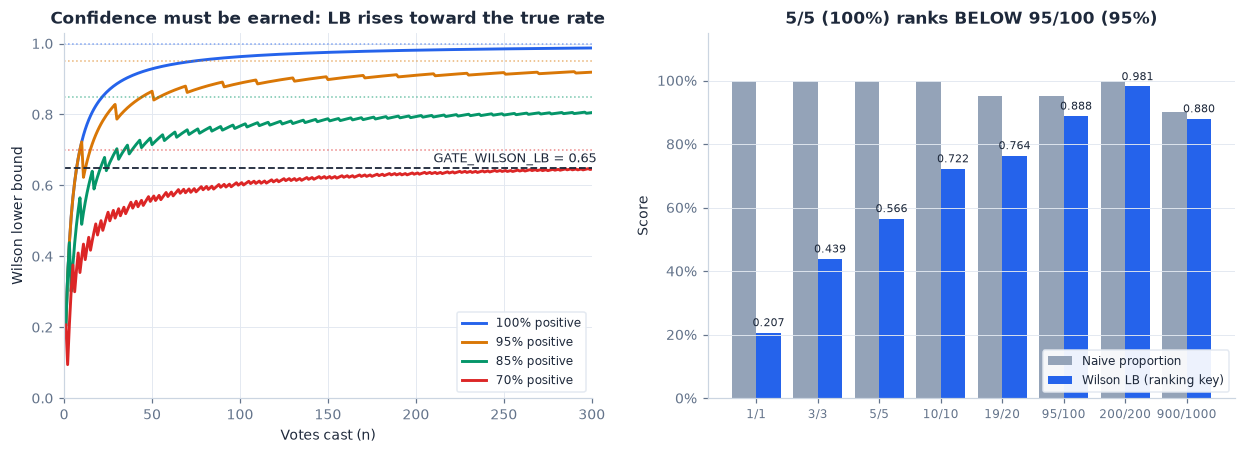


evidence        naive    wilson LB
1/1            100.0%       0.2065
3/3            100.0%       0.4385
5/5            100.0%       0.5655
10/10          100.0%       0.7225
19/20           95.0%       0.7639
95/100          95.0%       0.8882
200/200        100.0%       0.9812
900/1000        90.0%       0.8798


In [7]:
# Sweep 1: how the lower bound grows with evidence, at four fixed approval rates.
ns = list(range(1, 301))
rates = [1.00, 0.95, 0.85, 0.70]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 4.2))

for colour, p in zip(SERIES, rates):
    lb = [wilson_lower_bound(round(n * p), n) for n in ns]
    ax1.plot(ns, lb, color=colour, lw=1.9, label="%d%% positive" % round(p * 100))
    ax1.axhline(p, color=colour, ls=":", lw=1.0, alpha=0.55)

ax1.axhline(GATE_WILSON_LB, color=INK, ls="--", lw=1.2)
ax1.annotate("GATE_WILSON_LB = %.2f" % GATE_WILSON_LB, xy=(210, GATE_WILSON_LB + 0.015),
             fontsize=8.2, color=INK)
ax1.set_xlabel("Votes cast (n)")
ax1.set_ylabel("Wilson lower bound")
ax1.set_title("Confidence must be earned: LB rises toward the true rate")
ax1.set_ylim(0, 1.03); ax1.set_xlim(0, 300)
ax1.grid(True); ax1.legend(loc="lower right", fontsize=8)

# Sweep 2: the rank inversion that justifies the whole approach.
cases = [(1, 1), (3, 3), (5, 5), (10, 10), (19, 20), (95, 100), (200, 200), (900, 1000)]
labels = ["%d/%d" % c for c in cases]
naive = [k / n for k, n in cases]
wils = [wilson_lower_bound(k, n) for k, n in cases]
x = range(len(cases))
ax2.bar([i - 0.2 for i in x], naive, width=0.4, color=GREY, label="Naive proportion")
ax2.bar([i + 0.2 for i in x], wils, width=0.4, color=BLUE, label="Wilson LB (ranking key)")
for i, (nv, wv) in enumerate(zip(naive, wils)):
    ax2.text(i + 0.2, wv + 0.02, "%.3f" % wv, ha="center", fontsize=7.4, color=INK)
ax2.set_xticks(list(x)); ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylim(0, 1.15)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_title("5/5 (100%) ranks BELOW 95/100 (95%)")
ax2.set_ylabel("Score")
ax2.grid(True, axis="y"); ax2.legend(loc="lower right", fontsize=8)

fig.tight_layout()
print("saved:", save(fig, "wilson_lower_bound.png"))
plt.show()

print()
print("%-10s %10s %12s" % ("evidence", "naive", "wilson LB"))
for (k, n), nv, wv in zip(cases, naive, wils):
    print("%-10s %9.1f%% %12.4f" % ("%d/%d" % (k, n), nv * 100, wv))

**What this means for the product.** A newly published review with one perfect vote enters
the feed at **0.2065** and cannot displace anything. A 95/100 review outranks a 5/5 review
despite the lower headline percentage. This single property is what stops the feed being
dominated by whoever posted most recently and got a friend to up-vote — the sorting key is
`ORDER BY wilson_score DESC, created_at DESC` in `review_service.list_feed`, so this curve
*is* the homepage order.

## 1.2 Exponential recency decay

**The problem.** A Wilson score computed over all-time votes is a permanent ranking. A
review that won the homepage in January would still hold it in December, so the feed would
ossify and new contributors would have nothing to compete for — again undercutting the
incentive model.

**The decision.** Weight each vote by its age with an exponential half-life of **45 days**
(~1.5 evaluation months). A vote cast today counts 1.0; a vote cast 45 days ago counts 0.5.

**As implemented** (`decay_factor`): $w(t) = 0.5^{\,t / H}$ for $t > 0$, with $H = 45$ days,
and exactly `1.0` for $t \le 0$ (a clamp, so clock skew can never produce a weight above 1).

def decay_factor(age_days: float, half_life_days: float = DECAY_HALF_LIFE_DAYS) -> float:
    """Exponential recency weight in (0, 1]. age 0 -> 1.0; one half-life -> 0.5."""
    if age_days <= 0:
        return 1.0
    return 0.5 ** (age_days / half_life_days)



saved: docs/assets/notebooks/recency_decay.png


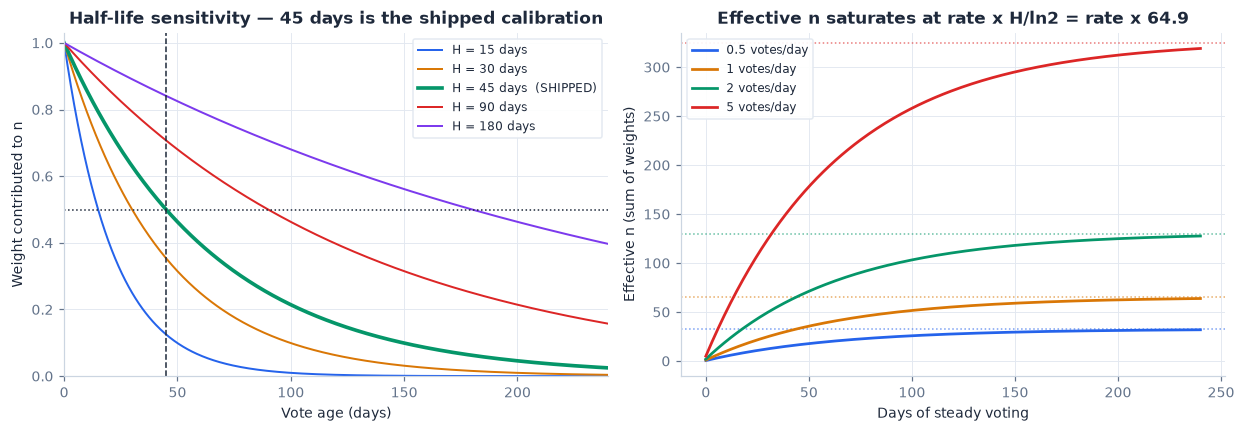

  age    0 d  ->  weight 1.0000
  age    7 d  ->  weight 0.8978
  age   30 d  ->  weight 0.6300
  age   45 d  ->  weight 0.5000
  age   90 d  ->  weight 0.2500
  age  135 d  ->  weight 0.1250
  age  180 d  ->  weight 0.0625
  age  365 d  ->  weight 0.0036

Steady-state effective-n ceiling for r votes/day: r x H/ln2 = r x 64.9213


In [8]:
print(inspect.getsource(decay_factor))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 4.0))

days = [d * 0.5 for d in range(0, 481)]
for colour, hl in zip(SERIES, [15.0, 30.0, DECAY_HALF_LIFE_DAYS, 90.0, 180.0]):
    w = [decay_factor(d, hl) for d in days]
    lw = 2.4 if hl == DECAY_HALF_LIFE_DAYS else 1.3
    label = "H = %g days%s" % (hl, "  (SHIPPED)" if hl == DECAY_HALF_LIFE_DAYS else "")
    ax1.plot(days, w, color=colour, lw=lw, label=label)
ax1.axvline(DECAY_HALF_LIFE_DAYS, color=INK, ls="--", lw=1.0)
ax1.axhline(0.5, color=INK, ls=":", lw=1.0)
ax1.set_xlabel("Vote age (days)"); ax1.set_ylabel("Weight contributed to n")
ax1.set_title("Half-life sensitivity — 45 days is the shipped calibration")
ax1.set_xlim(0, 240); ax1.set_ylim(0, 1.03)
ax1.grid(True); ax1.legend(fontsize=8)

# Steady state: a review earning r votes/day converges to an effective n of r*H/ln2.
ceiling = DECAY_HALF_LIFE_DAYS / math.log(2)
for colour, rate in zip(SERIES, [0.5, 1.0, 2.0, 5.0]):
    eff, horizon = [], list(range(0, 241))
    for day in horizon:
        eff.append(sum(rate * decay_factor(day - d) for d in range(0, day + 1)))
    ax2.plot(horizon, eff, color=colour, lw=1.8, label="%g votes/day" % rate)
    ax2.axhline(rate * ceiling, color=colour, ls=":", lw=1.0, alpha=0.6)
ax2.set_xlabel("Days of steady voting"); ax2.set_ylabel("Effective n (sum of weights)")
ax2.set_title("Effective n saturates at rate x H/ln2 = rate x %.1f" % ceiling)
ax2.grid(True); ax2.legend(fontsize=8)

fig.tight_layout()
print("saved:", save(fig, "recency_decay.png"))
plt.show()

for d in [0, 7, 30, 45, 90, 135, 180, 365]:
    print("  age %4d d  ->  weight %.4f" % (d, decay_factor(d)))
print("\nSteady-state effective-n ceiling for r votes/day: r x H/ln2 = r x %.4f" % ceiling)

**What this means for the product.** Decay is not just a tie-breaker — it caps how much
evidence a review can *hold*. A review earning one vote per day converges on an effective
n of ~64.9 no matter how long it runs, which bounds the Wilson lower bound it can reach.
An old champion therefore cannot accumulate an insurmountable lead, and the nightly
`vote_service.recompute_all_wilson_scores` sweep exists precisely because this score drifts
downward with the clock even when nobody votes.

## 1.3 Time-decayed Wilson — the score actually stored on every review

`time_decayed_wilson` composes §1.1 and §1.2: each vote contributes its decay weight to the
totals, then the Wilson lower bound is taken over those weighted totals. The result is
written to `reviews.wilson_score` inside the same transaction as the vote
(`vote_service.recompute_review_vote_aggregates`) and re-decayed nightly.

This is where accepting float counts in §1.1 pays off: the "n" fed to Wilson is a sum of
weights, not a count of rows.

In [9]:
print(inspect.getsource(time_decayed_wilson))

# Two reviews with identical raw tallies (90 up / 10 down) but different vote timing.
recent = [(i < 90, 3.0) for i in range(100)]     # all votes ~3 days old
stale  = [(i < 90, 200.0) for i in range(100)]   # all votes ~200 days old
mixed  = [(i < 90, float(i)) for i in range(100)]  # spread over 100 days

for label, votes in [("all 3 days old", recent), ("spread 0-99 days", mixed),
                     ("all 200 days old", stale)]:
    eff_n = sum(decay_factor(a) for _, a in votes)
    print("90 up / 10 down, %-18s -> effective n %7.2f   decayed Wilson %.4f" % (
        label, eff_n, time_decayed_wilson(votes)))

def time_decayed_wilson(
    votes: Iterable[tuple[bool, float]],
    z: float = WILSON_Z_95,
    half_life_days: float = DECAY_HALF_LIFE_DAYS,
) -> float:
    """Wilson lower bound over recency-weighted votes.

    `votes` is an iterable of (is_positive, age_days). Each vote contributes its
    decay weight to the totals, so older votes count less.
    """
    positive = 0.0
    total = 0.0
    for is_positive, age_days in votes:
        w = decay_factor(age_days, half_life_days)
        total += w
        if is_positive:
            positive += w
    return wilson_lower_bound(positive, total, z)

90 up / 10 down, all 3 days old     -> effective n   95.48   decayed Wilson 0.8235
90 up / 10 down, spread 0-99 days   -> effective n   51.40   decayed Wilson 0.8596
90 up / 10 down, all 200 days old   -> effective n    4.59   decayed Wilson 0.4455


saved: docs/assets/notebooks/time_decayed_wilson.png


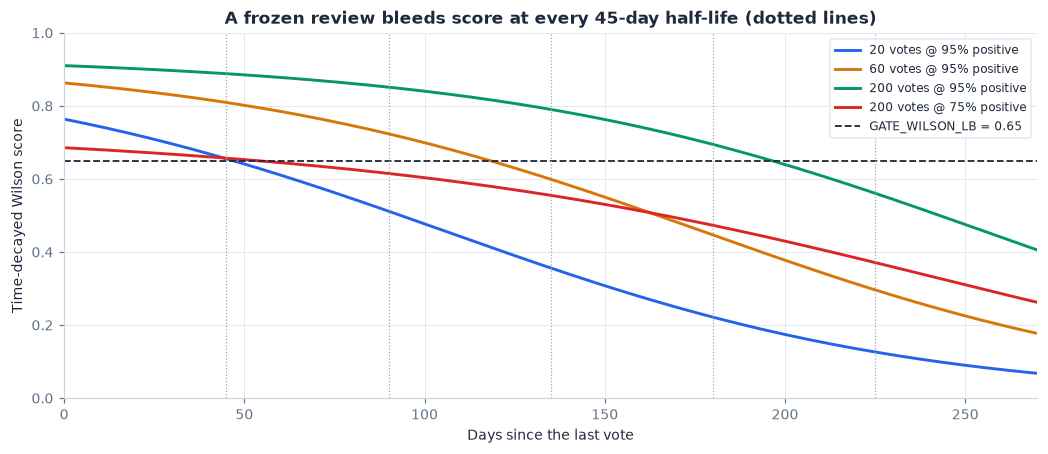

In [10]:
# How a single review's score evolves: a burst of votes on day 0, then silence.
horizon = list(range(0, 271))
fig, ax = plt.subplots(figsize=(9.6, 4.2))

for colour, (n_votes, rate) in zip(SERIES, [(20, 0.95), (60, 0.95), (200, 0.95), (200, 0.75)]):
    pos = round(n_votes * rate)
    series = []
    for day in horizon:
        votes = [(i < pos, float(day)) for i in range(n_votes)]
        series.append(time_decayed_wilson(votes))
    ax.plot(horizon, series, color=colour, lw=1.9,
            label="%d votes @ %d%% positive" % (n_votes, round(rate * 100)))

ax.axhline(GATE_WILSON_LB, color=INK, ls="--", lw=1.2, label="GATE_WILSON_LB = %.2f" % GATE_WILSON_LB)
for hl in range(1, 6):
    ax.axvline(hl * DECAY_HALF_LIFE_DAYS, color=GREY, ls=":", lw=0.8)
ax.set_xlabel("Days since the last vote")
ax.set_ylabel("Time-decayed Wilson score")
ax.set_title("A frozen review bleeds score at every 45-day half-life (dotted lines)")
ax.set_ylim(0, 1.0); ax.set_xlim(0, 270)
ax.grid(True); ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
print("saved:", save(fig, "time_decayed_wilson.png"))
plt.show()

## 1.4 The four vote-influx scenarios — reusing `backend/sim`

The repository already contains a seeded, deterministic simulation harness
(`backend/sim/scenarios.py`) that drives the *real* ranking functions through four
adversarial vote influxes, with 19 assertions in `backend/tests/test_ranking_simulation.py`
and four committed figures in `docs/assets/ranking/`. That harness is **reused here rather
than reimplemented**; this section recomputes its headline facts live and adds one compact
recap figure.

| Scenario | Question |
|---|---|
| S1 small-n vs large-n | Why Wilson instead of a naive percentage |
| S2 brigade burst | 200 up-votes in 10 minutes — how fast does it reach the homepage |
| S3 decay handover | Can a frozen champion be overtaken with no new votes |
| S4 down-vote raid | 150 down-votes in 10 minutes — does anything notice |

In [11]:
facts = S.headline_facts()
for k in sorted(facts):
    print("  %-34s %s" % (k, facts[k]))

  burst_first_flag_minute            1.0
  burst_minute_entering_homepage     1.0
  burst_minutes                      10.0
  burst_peak_hourly_upvotes          200
  burst_rank_after                   1
  burst_rank_before                  8
  burst_score_after                  0.9688880889304591
  burst_score_before                 0.4926068231107303
  burst_size                         200
  challenger_effective_n_final       55.27664294237865
  champion_effective_n_day0          100.0
  champion_effective_n_final         15.749013123685915
  decay_crossover_day                54
  decay_half_life_days               45.0
  gate_wilson_lb                     0.65
  homepage_slots                     6
  raid_any_velocity_flag             False
  raid_minute_below_gate             2.0
  raid_peak_hourly_downvotes         150
  raid_rank_after                    10
  raid_rank_before                   1
  raid_score_after                   0.2365469915305376
  raid_score_before        

saved: docs/assets/notebooks/sim_scenarios_recap.png


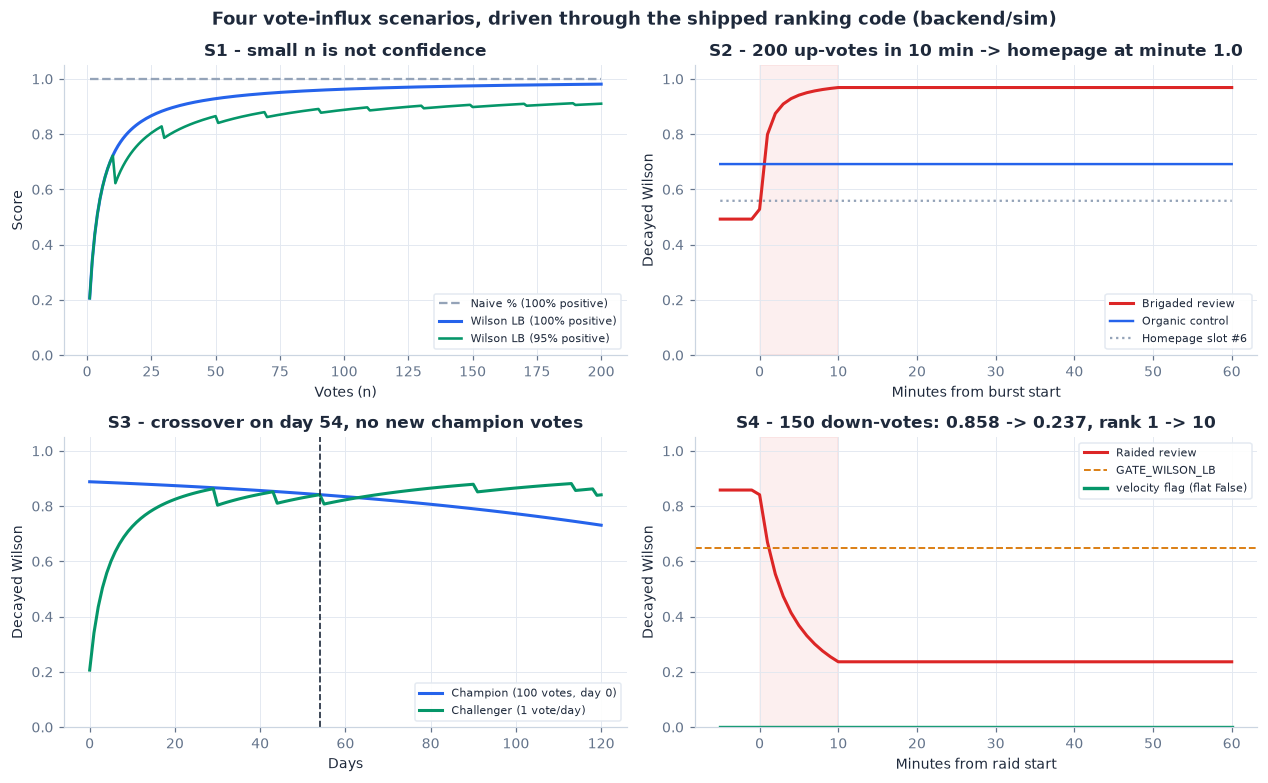

In [12]:
s2 = S.brigade_burst()
s3 = S.decay_handover()
s4 = S.downvote_raid()

fig, axes = plt.subplots(2, 2, figsize=(11.6, 7.2))

# S1 — Wilson vs naive.
s1 = S.small_n_vs_large_n()
ax = axes[0][0]
ax.plot(s1.counts, s1.naive["100% positive"], color=GREY, ls="--", lw=1.5, label="Naive % (100% positive)")
ax.plot(s1.counts, s1.wilson["100% positive"], color=BLUE, lw=2.0, label="Wilson LB (100% positive)")
ax.plot(s1.counts, s1.wilson["95% positive"], color=GREEN, lw=1.7, label="Wilson LB (95% positive)")
ax.set_title("S1 - small n is not confidence"); ax.set_xlabel("Votes (n)"); ax.set_ylabel("Score")
ax.set_ylim(0, 1.05); ax.grid(True); ax.legend(fontsize=7.5, loc="lower right")

# S2 — brigade burst.
ax = axes[0][1]
ax.axvspan(0, s2.burst_minutes, color=RED, alpha=0.07)
ax.plot(s2.minutes, s2.target_score, color=RED, lw=2.0, label="Brigaded review")
ax.plot(s2.minutes, s2.control_score, color=BLUE, lw=1.6, label="Organic control")
ax.plot(s2.minutes, s2.cutoff, color=GREY, ls=":", lw=1.5, label="Homepage slot #%d" % S.HOMEPAGE_SLOTS)
ax.set_title("S2 - %d up-votes in %g min -> homepage at minute %s"
             % (s2.burst_size, s2.burst_minutes, s2.minute_entering_homepage))
ax.set_xlabel("Minutes from burst start"); ax.set_ylabel("Decayed Wilson")
ax.set_ylim(0, 1.05); ax.grid(True); ax.legend(fontsize=7.5, loc="lower right")

# S3 — decay handover.
ax = axes[1][0]
ax.plot(s3.days, s3.champion_score, color=BLUE, lw=2.0, label="Champion (100 votes, day 0)")
ax.plot(s3.days, s3.challenger_score, color=GREEN, lw=2.0, label="Challenger (1 vote/day)")
ax.axvline(s3.crossover_day, color=INK, ls="--", lw=1.1)
ax.set_title("S3 - crossover on day %d, no new champion votes" % s3.crossover_day)
ax.set_xlabel("Days"); ax.set_ylabel("Decayed Wilson")
ax.set_ylim(0, 1.05); ax.grid(True); ax.legend(fontsize=7.5, loc="lower right")

# S4 — down-vote raid.
ax = axes[1][1]
ax.axvspan(0, s4.raid_minutes, color=RED, alpha=0.07)
ax.plot(s4.minutes, s4.score, color=RED, lw=2.0, label="Raided review")
ax.axhline(GATE_WILSON_LB, color=AMBER, ls="--", lw=1.2, label="GATE_WILSON_LB")
ax.plot(s4.minutes, [int(f) for f in s4.velocity_flag], color=GREEN, lw=2.2,
        label="velocity flag (flat False)")
ax.set_title("S4 - %d down-votes: %.3f -> %.3f, rank %d -> %d"
             % (s4.raid_size, s4.score_before, s4.score_after, s4.rank[0], s4.rank[-1]))
ax.set_xlabel("Minutes from raid start"); ax.set_ylabel("Decayed Wilson")
ax.set_ylim(0, 1.05); ax.grid(True); ax.legend(fontsize=7.5, loc="upper right")

fig.suptitle("Four vote-influx scenarios, driven through the shipped ranking code (backend/sim)",
             fontsize=12, fontweight="bold", color=INK)
fig.tight_layout()
print("saved:", save(fig, "sim_scenarios_recap.png"))
plt.show()

**What this means for the product.** Two findings from the harness are load-bearing and are
reproduced above rather than paraphrased:

- **F1 — a brigade wins before a moderator can blink.** 200 up-votes over 10 minutes lift a
  thin review from rank %s to rank %s and into the homepage top-6 within about a minute.
  The velocity flag *does* fire, but it is advisory only and surfaces on a moderator queue
  card; nothing is auto-blocked (an explicit FR-8 invariant).
- **F2 — down-votes are invisible to the velocity signal.** `fraud_service._velocity_flag`
  filters `vote == VoteDirection.up` before calling `velocity_exceeded`, so a 150-vote raid
  that drives a healthy review below the earn-eligible gate raises no signal at all. This is
  a real gap, documented rather than hidden.

## 1.5 Velocity detection — the surge signal

**The problem.** Coordinated vote brigades arrive in bursts. Volume alone is not suspicious;
volume *concentrated in time* is.

**The decision.** Flag when **more than 10 up-votes** land inside any **3600-second** sliding
window. Advisory only — fraud layer 5 never auto-blocks.

**As implemented** (`velocity_exceeded`): a two-pointer sliding window over the sorted vote
ages. The early-out `len(ages) <= threshold` makes the common case O(1); otherwise it is
O(n log n) for the sort plus O(n) for the scan.

Two exact behaviours worth pinning for the defense:

- The comparison is **strictly greater than** the threshold, so exactly 11 votes in an hour
  flag and exactly 10 do not.
- The window test is `ages[right] - ages[left] > window`, i.e. a **closed** window: 11 votes
  spread over exactly 3600 s still flag.

In [13]:
print(inspect.getsource(velocity_exceeded))

# Boundary behaviour, stated exactly.
for k in [9, 10, 11, 12]:
    ages = [i * (VELOCITY_WINDOW_SECONDS / max(1, k - 1)) for i in range(k)]  # exactly one hour wide
    print("  %2d up-votes spread over exactly %ds -> flag = %s"
          % (k, VELOCITY_WINDOW_SECONDS, velocity_exceeded(ages)))

def velocity_exceeded(
    upvote_ages_seconds: Sequence[float],
    window_seconds: int = VELOCITY_WINDOW_SECONDS,
    threshold: int = VELOCITY_THRESHOLD,
) -> bool:
    """True if > `threshold` upvotes fall within any `window_seconds` window.

    `upvote_ages_seconds` = seconds-ago for each upvote. Uses a sliding window
    over the sorted ages; advisory only (never auto-blocks — fraud layer 5).
    """
    if len(upvote_ages_seconds) <= threshold:
        return False
    ages = sorted(upvote_ages_seconds)
    left = 0
    for right in range(len(ages)):
        while ages[right] - ages[left] > window_seconds:
            left += 1
        if (right - left + 1) > threshold:
            return True
    return False

   9 up-votes spread over exactly 3600s -> flag = False
  10 up-votes spread over exactly 3600s -> flag = False
  11 up-votes spread over exactly 3600s -> flag = True
  12 up-votes spread over exactly 3600s -> flag = True


saved: docs/assets/notebooks/velocity_detection.png


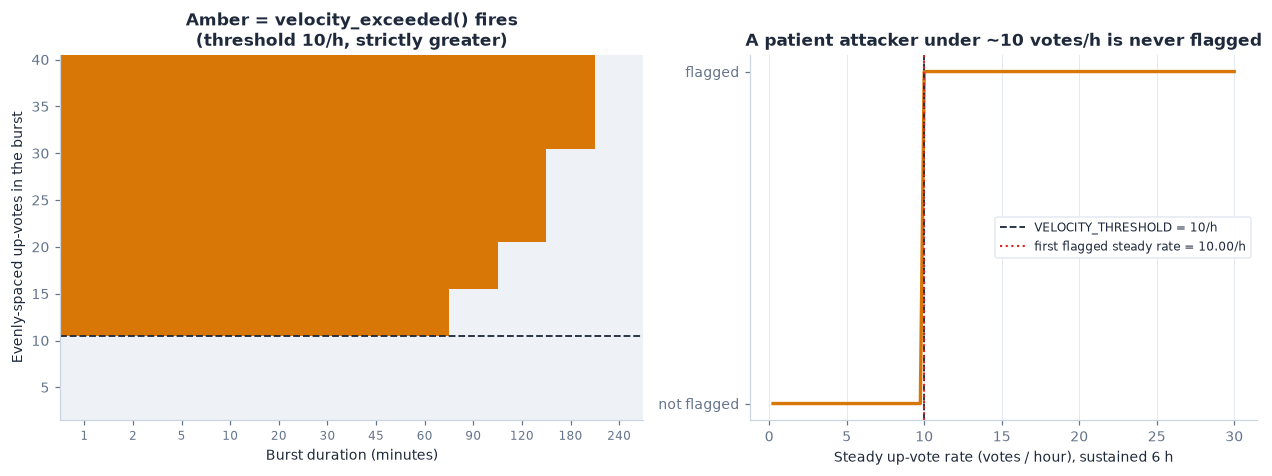


Sustained rate at which the flag first fires: 10.0 votes/hour


In [14]:
# Sweep: how many votes, over how long a span, does it take to trip the signal?
spans_min = [1, 2, 5, 10, 20, 30, 45, 60, 90, 120, 180, 240]
counts = list(range(2, 41))

grid = []
for k in counts:
    row = []
    for span in spans_min:
        span_s = span * 60.0
        ages = [i * span_s / max(1, k - 1) for i in range(k)]
        row.append(1 if velocity_exceeded(ages) else 0)
    grid.append(row)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.4),
                               gridspec_kw={"width_ratios": [1.15, 1]})

ax1.imshow(grid, aspect="auto", origin="lower", cmap=matplotlib.colors.ListedColormap(["#eef2f7", AMBER]),
           extent=[-0.5, len(spans_min) - 0.5, counts[0] - 0.5, counts[-1] + 0.5])
ax1.set_xticks(range(len(spans_min))); ax1.set_xticklabels(spans_min, fontsize=7.6)
ax1.set_xlabel("Burst duration (minutes)"); ax1.set_ylabel("Evenly-spaced up-votes in the burst")
ax1.axhline(VELOCITY_THRESHOLD + 0.5, color=INK, ls="--", lw=1.2)
ax1.set_title("Amber = velocity_exceeded() fires\n(threshold %d/h, strictly greater)"
              % VELOCITY_THRESHOLD)

# The evasion frontier: rate needed to stay under the flag.
rates = [x / 4 for x in range(1, 121)]  # votes per hour
flags = []
for r in rates:
    n = max(2, int(r * 6))          # six hours of steady voting
    gap = 3600.0 / r
    ages = [i * gap for i in range(n)]
    flags.append(velocity_exceeded(ages))
first_flag = next((r for r, f in zip(rates, flags) if f), None)
ax2.plot(rates, [int(f) for f in flags], color=AMBER, lw=2.2)
ax2.axvline(VELOCITY_THRESHOLD, color=INK, ls="--", lw=1.2,
            label="VELOCITY_THRESHOLD = %d/h" % VELOCITY_THRESHOLD)
if first_flag:
    ax2.axvline(first_flag, color=RED, ls=":", lw=1.4,
                label="first flagged steady rate = %.2f/h" % first_flag)
ax2.set_yticks([0, 1]); ax2.set_yticklabels(["not flagged", "flagged"])
ax2.set_xlabel("Steady up-vote rate (votes / hour), sustained 6 h")
ax2.set_title("A patient attacker under ~%.0f votes/h is never flagged" % VELOCITY_THRESHOLD)
ax2.grid(True, axis="x"); ax2.legend(fontsize=8, loc="center right")

fig.tight_layout()
print("saved:", save(fig, "velocity_detection.png"))
plt.show()
print("\nSustained rate at which the flag first fires: %s votes/hour" % first_flag)

**What this means for the product.** The signal catches the *impatient* brigade and nothing
else. An attacker who paces 10 up-votes per hour — 240 a day — is permanently invisible to
this layer, and 240/day is far above anything an organic review receives. The signal is
therefore a tripwire for clumsy attacks, not a defence; the actual defence is the moderator
queue it feeds, plus proof-of-purchase verification upstream.

## 1.6 Reciprocity and collusion signals

Two closely related signals exist, and they are **not the same function**:

| | `ranking.reciprocity_flag` | `fraud_service._collusion_flag` |
|---|---|---|
| Scope | one *pair* of voters | one *review* vs its up-voters |
| Inputs | shared targets, reciprocal pairs | distinct up-voters V, author A |
| Fires when | reciprocal rate > 0.60 over >= 5 shared targets | \|V\| >= 5 and (voters A up-voted back)/\|V\| > 0.60 |
| Constants | `RECIPROCITY_*` | `COLLUSION_*` (same numeric values) |
| **Wired?** | **NOT WIRED** — no caller in `app/` | Wired: computed per moderator-queue card |

`reciprocity_flag` is unit-tested and documented in ADR-004 but has no production caller;
`fraud_service` implements the review-level variant directly in SQL. Both are simulated below,
and the notebook does not pretend the pairwise one is live.

reciprocity_flag -> backend/app/services/ranking.py:102   (NOT WIRED: no caller in app/)
def reciprocity_flag(
    shared_targets: int,
    reciprocal_pairs: int,
    min_shared: int = RECIPROCITY_MIN_SHARED,
    threshold: float = RECIPROCITY_THRESHOLD,
) -> bool:
    """Pairwise collusion signal (fraud layer, advisory).

    `shared_targets` = content both voters voted on; `reciprocal_pairs` = of those,
    how many were mutual upvotes. Flags only above a minimum sample.
    """
    if shared_targets < min_shared:
        return False
    return (reciprocal_pairs / shared_targets) > threshold



saved: docs/assets/notebooks/reciprocity_collusion.png


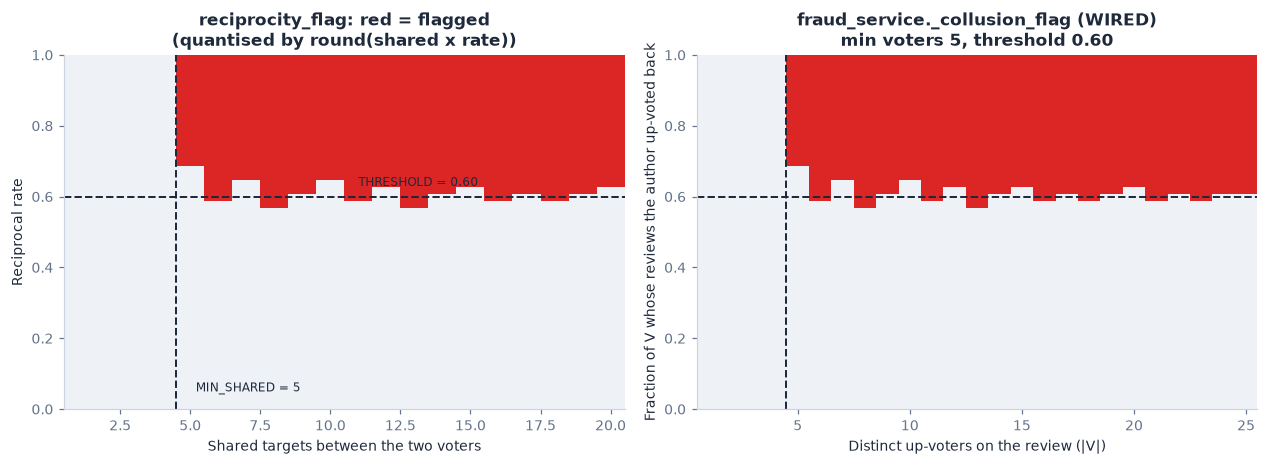


Smallest flagging cases:
  |V| =  3 -> can never flag
  |V| =  4 -> can never flag
  |V| =  5 -> needs 4 reciprocated (80%)
  |V| =  6 -> needs 4 reciprocated (67%)
  |V| =  7 -> needs 5 reciprocated (71%)
  |V| =  8 -> needs 5 reciprocated (62%)
  |V| =  9 -> needs 6 reciprocated (67%)
  |V| = 10 -> needs 7 reciprocated (70%)


In [15]:
print("reciprocity_flag ->", cite(reciprocity_flag), "  (NOT WIRED: no caller in app/)")
print(inspect.getsource(reciprocity_flag))

shared = list(range(1, 21))
rate_axis = [x / 100 for x in range(0, 101, 2)]
grid = [[1 if reciprocity_flag(s, round(s * r)) else 0 for s in shared] for r in rate_axis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.3))
ax1.imshow(grid, aspect="auto", origin="lower",
           cmap=matplotlib.colors.ListedColormap(["#eef2f7", RED]),
           extent=[shared[0] - 0.5, shared[-1] + 0.5, 0, 1])
ax1.axvline(RECIPROCITY_MIN_SHARED - 0.5, color=INK, ls="--", lw=1.3)
ax1.axhline(RECIPROCITY_THRESHOLD, color=INK, ls="--", lw=1.3)
ax1.text(RECIPROCITY_MIN_SHARED + 0.2, 0.05, "MIN_SHARED = %d" % RECIPROCITY_MIN_SHARED,
         fontsize=8, color=INK)
ax1.text(11, RECIPROCITY_THRESHOLD + 0.03, "THRESHOLD = %.2f" % RECIPROCITY_THRESHOLD,
         fontsize=8, color=INK)
ax1.set_xlabel("Shared targets between the two voters")
ax1.set_ylabel("Reciprocal rate")
ax1.set_title("reciprocity_flag: red = flagged\n(quantised by round(shared x rate))")

# Review-level collusion (the wired one), reimplemented from fraud_service.py:49-68.
def collusion_flag(n_voters: int, n_reciprocated: int) -> bool:
    if n_voters < COLLUSION_MIN_VOTERS:
        return False
    return (n_reciprocated / n_voters) > COLLUSION_THRESHOLD

voters = list(range(1, 26))
frac = [x / 100 for x in range(0, 101, 2)]
grid2 = [[1 if collusion_flag(v, round(v * f)) else 0 for v in voters] for f in frac]
ax2.imshow(grid2, aspect="auto", origin="lower",
           cmap=matplotlib.colors.ListedColormap(["#eef2f7", RED]),
           extent=[voters[0] - 0.5, voters[-1] + 0.5, 0, 1])
ax2.axvline(COLLUSION_MIN_VOTERS - 0.5, color=INK, ls="--", lw=1.3)
ax2.axhline(COLLUSION_THRESHOLD, color=INK, ls="--", lw=1.3)
ax2.set_xlabel("Distinct up-voters on the review (|V|)")
ax2.set_ylabel("Fraction of V whose reviews the author up-voted back")
ax2.set_title("fraud_service._collusion_flag (WIRED)\nmin voters %d, threshold %.2f"
              % (COLLUSION_MIN_VOTERS, COLLUSION_THRESHOLD))
fig.tight_layout()
print("saved:", save(fig, "reciprocity_collusion.png"))
plt.show()

print("\nSmallest flagging cases:")
for v in range(3, 11):
    need = next((k for k in range(v + 1) if collusion_flag(v, k)), None)
    print("  |V| = %2d -> needs %s reciprocated (%.0f%%)"
          % (v, need, 100 * need / v) if need is not None else "  |V| = %2d -> can never flag" % v)

**What this means for the product.** The minimum-sample guard is doing most of the work: a
ring of four accounts up-voting each other can never be flagged, no matter how blatant, because
`|V| < 5`. Once the ring reaches five, four of the five must be reciprocated (80% > 60%) before
the card is marked. The signal is designed to have a very low false-positive rate at the cost of
missing small rings — a defensible choice when the output goes to a human queue, and a poor one
if it were ever used to auto-remove content.

## 1.7 Publication gate and phase transition — **NOT WIRED**

`gate_passes` and `is_post_seeding` encode FR-6's earn-eligible gate (Wilson LB on effective n
>= 0.65 **and** >= 3 Stage-2+ voters) and the PRD §2 Seeding -> Post-Seeding transition (>= 50
Stage-2+ verified reviewers). Both are pure, both are unit-tested — and neither has a caller
anywhere in `app/`. In the shipped system, publication and monetisation routing are **manual**:
a moderator calls `referral_service.attach_affiliate_link` (>= 3 stars, verified) or
`publish_without_link` (<= 2 stars -> Honesty Fund). The gate is the automation these functions
were written for, staged for a later milestone.

This is stated plainly because a defense panel will ask whether the platform auto-monetises
content. It does not.

backend/app/services/ranking.py:118  <- NOT WIRED (pure function, tests only)
backend/app/services/ranking.py:125  <- NOT WIRED (pure function, tests only)

def gate_passes(effective_positive: float, effective_total: float,
                stage2_plus_voters: int) -> bool:
    """Post-Seeding auto-queue gate: Wilson LB (effective n) >= 0.65 AND >= 3 Stage-2+ voters."""
    lb = wilson_lower_bound(effective_positive, effective_total)
    return lb >= GATE_WILSON_LB and stage2_plus_voters >= GATE_MIN_STAGE2_VOTERS



saved: docs/assets/notebooks/publication_gate.png


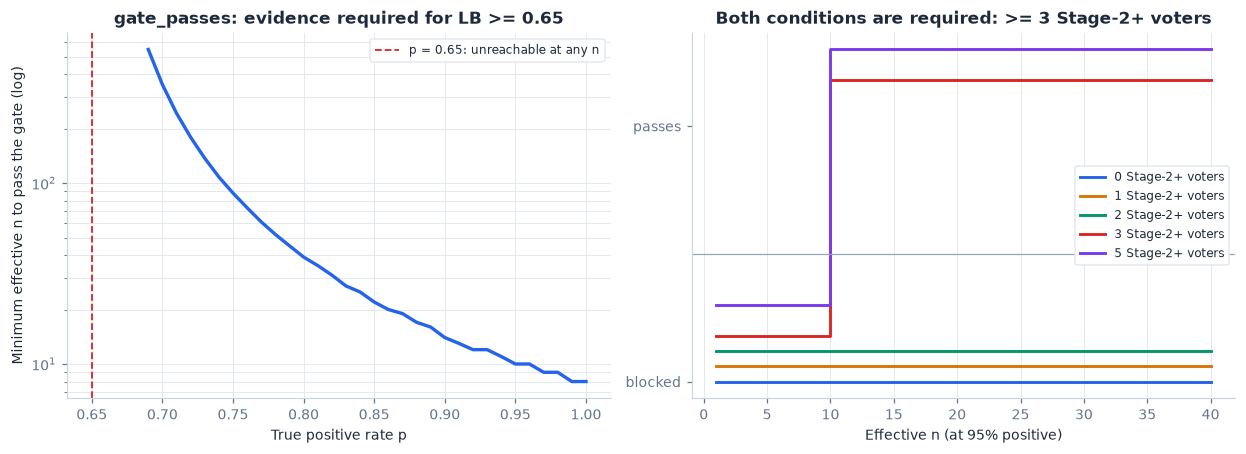


Minimum effective n by true positive rate:
  p = 0.70 -> n >= 350
  p = 0.75 -> n >= 88
  p = 0.80 -> n >= 39
  p = 0.85 -> n >= 22
  p = 0.90 -> n >= 14
  p = 0.95 -> n >= 10
  p = 1.00 -> n >= 8

is_post_seeding threshold = 50 Stage-2+ reviewers; 49 -> False, 50 -> True


In [16]:
for fn in (gate_passes, is_post_seeding):
    print(cite(fn), " <- NOT WIRED (pure function, tests only)")
print()
print(inspect.getsource(gate_passes))

# What the gate WOULD require: minimum effective n at each true positive rate.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 4.2))

prates = [x / 100 for x in range(60, 101)]
min_n = []
for p in prates:
    found = None
    for n in range(1, 601):
        if wilson_lower_bound(p * n, n) >= GATE_WILSON_LB:
            found = n
            break
    min_n.append(found if found else float("nan"))
ax1.plot(prates, min_n, color=BLUE, lw=2.2)
ax1.axvline(GATE_WILSON_LB, color=RED, ls="--", lw=1.2,
            label="p = %.2f: unreachable at any n" % GATE_WILSON_LB)
ax1.set_yscale("log")
ax1.set_xlabel("True positive rate p")
ax1.set_ylabel("Minimum effective n to pass the gate (log)")
ax1.set_title("gate_passes: evidence required for LB >= %.2f" % GATE_WILSON_LB)
ax1.grid(True, which="both"); ax1.legend(fontsize=8)

# The second half of the gate is a hard voter-quality floor.
n_axis = list(range(1, 41))
for colour, stage2 in zip(SERIES, [0, 1, 2, 3, 5]):
    passes = [1 if gate_passes(0.95 * n, n, stage2) else 0 for n in n_axis]
    ax2.step(n_axis, [v + stage2 * 0.06 for v in passes], where="post", color=colour, lw=1.9,
             label="%d Stage-2+ voters" % stage2)
ax2.axhline(0.5, color=GREY, lw=0.8)
ax2.set_yticks([0, 1]); ax2.set_yticklabels(["blocked", "passes"])
ax2.set_xlabel("Effective n (at 95% positive)")
ax2.set_title("Both conditions are required: >= %d Stage-2+ voters" % GATE_MIN_STAGE2_VOTERS)
ax2.grid(True, axis="x"); ax2.legend(fontsize=8, loc="center right")

fig.tight_layout()
print("saved:", save(fig, "publication_gate.png"))
plt.show()

print("\nMinimum effective n by true positive rate:")
for p in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00]:
    n = next((n for n in range(1, 601) if wilson_lower_bound(p * n, n) >= GATE_WILSON_LB), None)
    print("  p = %.2f -> n >= %s" % (p, n))
print("\nis_post_seeding threshold = %d Stage-2+ reviewers; 49 -> %s, 50 -> %s"
      % (SEEDING_TRANSITION_REVIEWERS, is_post_seeding(49), is_post_seeding(50)))

---
# Part 2 — Reputation and trust progression

`backend/app/services/trust.py` answers a question the source specification left undefined:
what *is* a user's "trust score percentage"? [ADR-003](../adr/003-reputation-score-formula.md)
pins it to a deterministic 0-100 blend so that gate vote weights become testable rather than
editorial.

## 2.1 `reputation_score` — the 0-100 blend

**The problem.** Trust multiplies vote weight and unlocks earning. An undefined trust score is
an unfalsifiable one, and a capstone cannot defend a number nobody can recompute.

**The decision** (ADR-003): four components, capped so that maxed components sum to exactly 100.

| Component | Formula | Cap |
|---|---|---|
| Helpfulness | `0.60 x helpfulness_ratio` (ratio in 0-100) | 60 |
| Verified-review volume | `10 x log10(1 + n)` | 25 |
| Best Answers | `3 x best_answer_count` | 15 |
| Strike penalty | `-15 x strikes` | uncapped, subtractive |

$$
\mathrm{score} = \mathrm{clamp}\Big(0.6\,h \;+\; \min(25,\, 10\log_{10}(1+v)) \;+\; \min(15,\, 3b) \;-\; 15s,\;\; 0,\; 100\Big)
$$

The logarithm is the interesting choice: volume should count, but the 500th verified review
must be worth far less than the 5th, or the score degenerates into a post-count leaderboard —
exactly the "reward volume over substance" failure the platform exists to correct.

In [17]:
print(inspect.getsource(reputation_score))
print("Weights read live: W_HELPFULNESS=%.2f VOLUME_CAP=%.0f VOLUME_COEFF=%.0f "
      "BEST_ANSWER_CAP=%.0f BEST_ANSWER_COEFF=%.0f STRIKE_PENALTY=%.0f"
      % (W_HELPFULNESS, VOLUME_CAP, VOLUME_COEFF, BEST_ANSWER_CAP,
         BEST_ANSWER_COEFF, STRIKE_PENALTY))
print("Volume cap reached at n =",
      next(n for n in range(1, 10000) if VOLUME_COEFF * math.log10(1 + n) >= VOLUME_CAP),
      "verified reviews; Best-Answer cap at b =",
      next(b for b in range(0, 100) if BEST_ANSWER_COEFF * b >= BEST_ANSWER_CAP))

def reputation_score(
    helpfulness_ratio: float,
    verified_review_count: int,
    best_answer_count: int,
    strikes: int,
) -> float:
    """Deterministic trust score in [0, 100]."""
    helpfulness = W_HELPFULNESS * max(0.0, min(100.0, helpfulness_ratio))
    volume = min(VOLUME_CAP, VOLUME_COEFF * math.log10(1 + max(0, verified_review_count)))
    best_answers = min(BEST_ANSWER_CAP, BEST_ANSWER_COEFF * max(0, best_answer_count))
    raw = helpfulness + volume + best_answers - STRIKE_PENALTY * max(0, strikes)
    return max(0.0, min(100.0, raw))

Weights read live: W_HELPFULNESS=0.60 VOLUME_CAP=25 VOLUME_COEFF=10 BEST_ANSWER_CAP=15 BEST_ANSWER_COEFF=3 STRIKE_PENALTY=15
Volume cap reached at n = 316 verified reviews; Best-Answer cap at b = 5


saved: docs/assets/notebooks/reputation_score.png


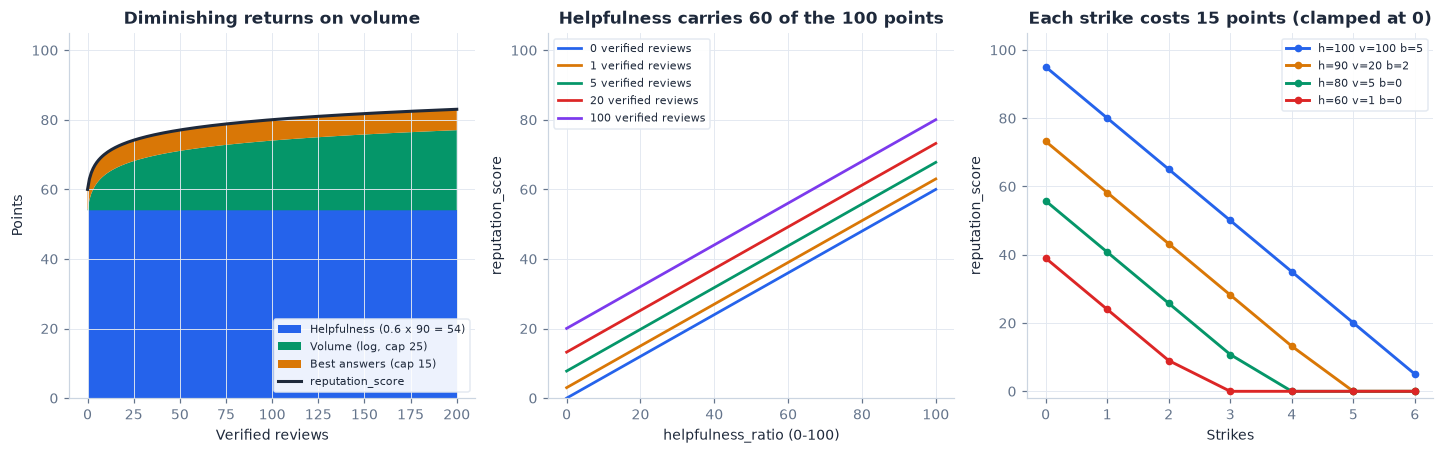


Worked profiles:
  brand-new member       ->   0.00
  solid contributor      ->  65.14
  community expert       ->  91.08
  theoretical maximum    -> 100.00
  expert with 1 strike   ->  76.08
  expert with 3 strikes  ->  46.08


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2))

# (a) Component decomposition as volume grows, at 90% helpfulness, 2 best answers.
vols = list(range(0, 201))
helpful_c = [W_HELPFULNESS * 90 for _ in vols]
volume_c = [min(VOLUME_CAP, VOLUME_COEFF * math.log10(1 + v)) for v in vols]
best_c = [min(BEST_ANSWER_CAP, BEST_ANSWER_COEFF * 2) for _ in vols]
axes[0].stackplot(vols, helpful_c, volume_c, best_c,
                  colors=[BLUE, GREEN, AMBER],
                  labels=["Helpfulness (0.6 x 90 = 54)", "Volume (log, cap 25)", "Best answers (cap 15)"])
axes[0].plot(vols, [reputation_score(90, v, 2, 0) for v in vols], color=INK, lw=2.0,
             label="reputation_score")
axes[0].set_xlabel("Verified reviews"); axes[0].set_ylabel("Points")
axes[0].set_title("Diminishing returns on volume")
axes[0].set_ylim(0, 105); axes[0].grid(True); axes[0].legend(fontsize=7.4, loc="lower right")

# (b) Helpfulness dominates.
h_axis = list(range(0, 101))
for colour, v in zip(SERIES, [0, 1, 5, 20, 100]):
    axes[1].plot(h_axis, [reputation_score(h, v, 0, 0) for h in h_axis], color=colour, lw=1.8,
                 label="%d verified reviews" % v)
axes[1].set_xlabel("helpfulness_ratio (0-100)"); axes[1].set_ylabel("reputation_score")
axes[1].set_title("Helpfulness carries 60 of the 100 points")
axes[1].set_ylim(0, 105); axes[1].grid(True); axes[1].legend(fontsize=7.4)

# (c) The strike cliff.
strikes = list(range(0, 7))
for colour, prof in zip(SERIES, [(100, 100, 5), (90, 20, 2), (80, 5, 0), (60, 1, 0)]):
    h, v, b = prof
    axes[2].plot(strikes, [reputation_score(h, v, b, s) for s in strikes], color=colour,
                 lw=1.9, marker="o", ms=4, label="h=%d v=%d b=%d" % prof)
axes[2].set_xlabel("Strikes"); axes[2].set_ylabel("reputation_score")
axes[2].set_title("Each strike costs %d points (clamped at 0)" % STRIKE_PENALTY)
axes[2].set_ylim(-2, 105); axes[2].grid(True); axes[2].legend(fontsize=7.4)

fig.tight_layout()
print("saved:", save(fig, "reputation_score.png"))
plt.show()

print("\nWorked profiles:")
for label, args in [("brand-new member", (0.0, 0, 0, 0)),
                    ("solid contributor", (85.0, 12, 1, 0)),
                    ("community expert", (95.0, 80, 6, 0)),
                    ("theoretical maximum", (100.0, 10000, 100, 0)),
                    ("expert with 1 strike", (95.0, 80, 6, 1)),
                    ("expert with 3 strikes", (95.0, 80, 6, 3))]:
    print("  %-22s -> %6.2f" % (label, reputation_score(*args)))

**What this means for the product.** The score is deliberately hard to farm. Volume alone caps
at 25 points — a user with 10,000 verified reviews and no community approval sits at 25/100.
Helpfulness is the only path past 60, and helpfulness is other people's votes, which are
themselves Wilson- and decay-governed. A single strike (-15) erases roughly 300 verified
reviews' worth of volume credit; three strikes erase everything a maxed volume-and-answers
profile can accumulate.

## 2.2 Trust-stage ladder — `determine_stage`

Six stages (0-5), evaluated **highest-first** so a qualifying user always lands on the top stage
they have unlocked. Stages move only through `trust_service.recompute_user_trust`; there is no
manual stage-set endpoint anywhere in the API.

| Stage | Requirement (all conditions) |
|---|---|
| 5 | >= 50 verified reviews, helpfulness >= 90, >= 6 months active |
| 4 | >= 15 verified, 0 strikes, >= 3 Best Answers, helpfulness >= 80 |
| 3 | >= 5 verified, helpfulness >= 70 |
| 2 | >= 1 verified review |
| 1 | >= 1 review (any) |
| 0 | otherwise |

Note the asymmetry: only Stage 4 requires zero strikes. A user with strikes can still reach
Stage 5 if the volume/helpfulness/tenure conditions hold — an artefact of the ordered checks
worth flagging rather than glossing over.

In [19]:
print(inspect.getsource(determine_stage))

# The strike asymmetry, demonstrated rather than asserted.
print("50 verified, 95% helpful, 12 months, 0 strikes -> stage",
      determine_stage(50, 50, 95.0, 5, 0, 12.0))
print("50 verified, 95% helpful, 12 months, 4 strikes -> stage",
      determine_stage(50, 50, 95.0, 5, 4, 12.0), " <- strikes do not block Stage 5")
print("20 verified, 85% helpful, 12 months, 1 strike  -> stage",
      determine_stage(20, 20, 85.0, 5, 1, 12.0), " <- but they do block Stage 4")

def determine_stage(
    review_count: int,
    verified_review_count: int,
    helpfulness_ratio: float,
    best_answer_count: int,
    strikes: int,
    months_active: float,
) -> int:
    """Highest unlocked trust stage (FR-7). Returns 0..5."""
    if (verified_review_count >= 50 and helpfulness_ratio >= 90 and months_active >= 6):
        return 5
    if (verified_review_count >= 15 and strikes == 0
            and best_answer_count >= 3 and helpfulness_ratio >= 80):
        return 4
    if verified_review_count >= 5 and helpfulness_ratio >= 70:
        return 3
    if verified_review_count >= 1:
        return 2
    if review_count >= 1:
        return 1
    return 0

50 verified, 95% helpful, 12 months, 0 strikes -> stage 5
50 verified, 95% helpful, 12 months, 4 strikes -> stage 5  <- strikes do not block Stage 5
20 verified, 85% helpful, 12 months, 1 strike  -> stage 3  <- but they do block Stage 4


saved: docs/assets/notebooks/trust_stage_ladder.png


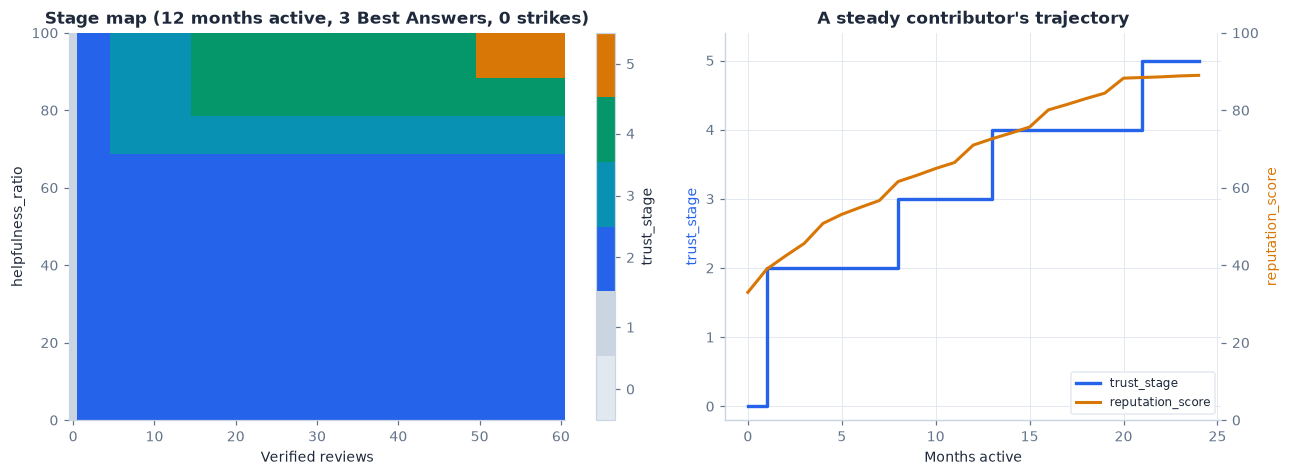

In [20]:
# Stage map over (verified reviews, helpfulness), holding tenure and best answers generous.
v_axis = list(range(0, 61))
h_axis = list(range(0, 101, 2))
stage_grid = [[determine_stage(max(1, v), v, float(h), 3, 0, 12.0) for v in v_axis]
              for h in h_axis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 4.4),
                               gridspec_kw={"width_ratios": [1.25, 1]})
cmap = matplotlib.colors.ListedColormap(["#e2e8f0", "#cbd5e1", BLUE, TEAL, GREEN, AMBER])
im = ax1.imshow(stage_grid, aspect="auto", origin="lower", cmap=cmap, vmin=0, vmax=5,
                extent=[v_axis[0] - 0.5, v_axis[-1] + 0.5, 0, 100])
cbar = fig.colorbar(im, ax=ax1, ticks=[0.4, 1.2, 2.1, 2.9, 3.7, 4.6])
cbar.ax.set_yticklabels(["0", "1", "2", "3", "4", "5"]); cbar.set_label("trust_stage")
ax1.set_xlabel("Verified reviews"); ax1.set_ylabel("helpfulness_ratio")
ax1.set_title("Stage map (12 months active, 3 Best Answers, 0 strikes)")

# A realistic career: stage and reputation over 24 months of steady contribution.
months = list(range(0, 25))
stages, scores = [], []
for m in months:
    verified = int(m * 2.4)              # ~2.4 verified reviews a month
    best = min(6, m // 4)
    helpful = min(94.0, 55.0 + 2.0 * m)  # reputation grows with the community
    stages.append(determine_stage(max(verified, 1) if m else 0, verified, helpful, best, 0, float(m)))
    scores.append(reputation_score(helpful, verified, best, 0))
ax2.step(months, stages, where="post", color=BLUE, lw=2.2, label="trust_stage")
ax2b = ax2.twinx()
ax2b.plot(months, scores, color=AMBER, lw=2.0, label="reputation_score")
ax2b.set_ylabel("reputation_score", color=AMBER); ax2b.set_ylim(0, 100)
ax2.set_xlabel("Months active"); ax2.set_ylabel("trust_stage", color=BLUE)
ax2.set_yticks(range(0, 6)); ax2.set_ylim(-0.2, 5.4)
ax2.set_title("A steady contributor's trajectory")
ax2.grid(True)
lines = ax2.get_lines() + ax2b.get_lines()
ax2.legend(lines, [l.get_label() for l in lines], fontsize=8, loc="lower right")

fig.tight_layout()
print("saved:", save(fig, "trust_stage_ladder.png"))
plt.show()

## 2.3 Gate vote weight — how trust converts into influence

**The problem.** One-member-one-vote hands a brand-new sock-puppet the same power as a member
with a two-year verified track record. Weighting by trust is the structural answer.

**As implemented** (`gate_vote_weight`):

- Stage 0 or on probation -> **0.0** (no gate voting at all)
- Stage 1 -> flat **0.25**, independent of reputation
- Stage 2+ -> `STAGE_MULTIPLIER[stage] x (reputation_score / 100)`
- Accounts younger than `ACCOUNT_MATURATION_DAYS` (30) -> **halved**

Multipliers: `{0: 0.0, 1: 0.25, 2: 1.0, 3: 1.5, 4: 2.0, 5: 3.0}`.

This function is *wired* — it is the weighting used by the Honesty Fund distribution
(Part 4.3), which makes it a money-moving algorithm, not just a governance one.

In [21]:
print(inspect.getsource(gate_vote_weight))
print("STAGE_MULTIPLIER =", STAGE_MULTIPLIER)
print("ACCOUNT_MATURATION_DAYS =", ACCOUNT_MATURATION_DAYS)

def gate_vote_weight(
    trust_stage: int,
    reputation_score_value: float,
    account_age_days: int,
    is_on_probation: bool,
) -> float:
    """earn_eligible gate vote weight (FR-7).

    Stage 0 = 0 (no gate voting). Stage 1 = flat 0.25. Stage 2+ = multiplier x
    trust%. Accounts < 30 days: halved. Probation: 0.
    """
    if is_on_probation or trust_stage <= 0:
        return 0.0
    if trust_stage == 1:
        weight = STAGE_MULTIPLIER[1]
    else:
        trust_pct = max(0.0, min(100.0, reputation_score_value)) / 100.0
        weight = STAGE_MULTIPLIER.get(trust_stage, 0.0) * trust_pct
    if account_age_days < ACCOUNT_MATURATION_DAYS:
        weight *= 0.5
    return weight

STAGE_MULTIPLIER = {0: 0.0, 1: 0.25, 2: 1.0, 3: 1.5, 4: 2.0, 5: 3.0}
ACCOUNT_MATURATION_DAYS = 30


saved: docs/assets/notebooks/gate_vote_weight.png


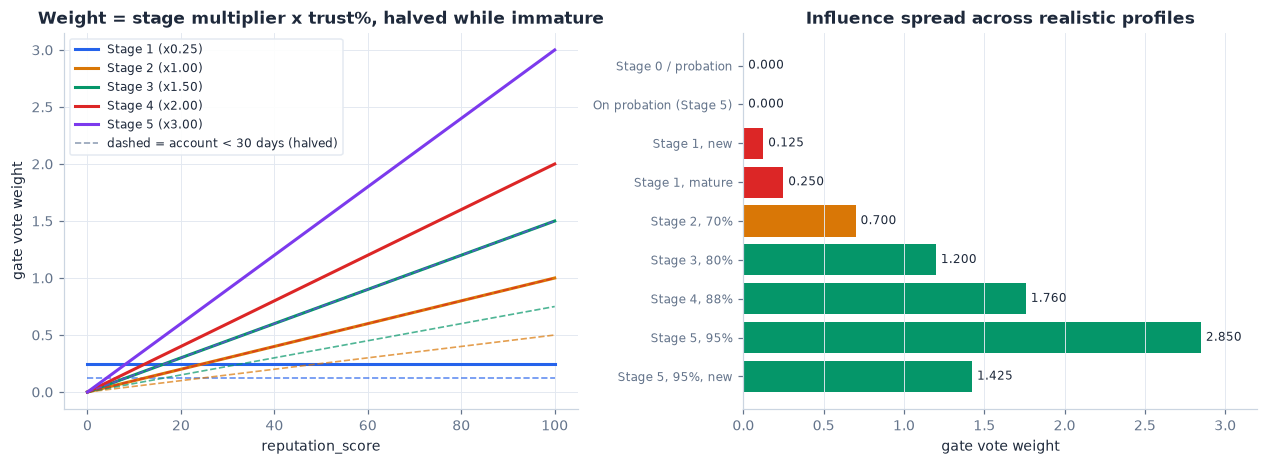


Stage-5/95% weight = 2.8500; Stage-1 weight = 0.2500 -> ratio 11.4x
Probation zeroes a Stage-5 member entirely: 0.0000


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.3))

rep_axis = [x for x in range(0, 101)]
for colour, stage in zip(SERIES, [1, 2, 3, 4, 5]):
    ax1.plot(rep_axis, [gate_vote_weight(stage, r, 400, False) for r in rep_axis],
             color=colour, lw=2.0, label="Stage %d (x%.2f)" % (stage, STAGE_MULTIPLIER[stage]))
    ax1.plot(rep_axis, [gate_vote_weight(stage, r, 10, False) for r in rep_axis],
             color=colour, lw=1.1, ls="--", alpha=0.7)
ax1.plot([], [], color=GREY, ls="--", lw=1.1, label="dashed = account < %d days (halved)"
         % ACCOUNT_MATURATION_DAYS)
ax1.set_xlabel("reputation_score"); ax1.set_ylabel("gate vote weight")
ax1.set_title("Weight = stage multiplier x trust%, halved while immature")
ax1.grid(True); ax1.legend(fontsize=7.6, loc="upper left")

# Effective influence spread: how many Stage-1 votes equal one Stage-5 vote?
profiles = [("Stage 0 / probation", 0, 0.0, 400, False),
            ("On probation (Stage 5)", 5, 95.0, 400, True),
            ("Stage 1, new", 1, 20.0, 5, False),
            ("Stage 1, mature", 1, 20.0, 400, False),
            ("Stage 2, 70%", 2, 70.0, 400, False),
            ("Stage 3, 80%", 3, 80.0, 400, False),
            ("Stage 4, 88%", 4, 88.0, 400, False),
            ("Stage 5, 95%", 5, 95.0, 400, False),
            ("Stage 5, 95%, new", 5, 95.0, 10, False)]
names = [p[0] for p in profiles]
weights = [gate_vote_weight(p[1], p[2], p[3], p[4]) for p in profiles]
colours = [GREY if w == 0 else (RED if w < 0.3 else (AMBER if w < 1.0 else GREEN)) for w in weights]
ax2.barh(range(len(profiles)), weights, color=colours)
ax2.set_yticks(range(len(profiles))); ax2.set_yticklabels(names, fontsize=8)
ax2.invert_yaxis()
for i, w in enumerate(weights):
    ax2.text(w + 0.03, i, "%.3f" % w, va="center", fontsize=8, color=INK)
ax2.set_xlabel("gate vote weight")
ax2.set_title("Influence spread across realistic profiles")
ax2.set_xlim(0, 3.2); ax2.grid(True, axis="x")

fig.tight_layout()
print("saved:", save(fig, "gate_vote_weight.png"))
plt.show()

top = gate_vote_weight(5, 95.0, 400, False)
bottom = gate_vote_weight(1, 20.0, 400, False)
print("\nStage-5/95%% weight = %.4f; Stage-1 weight = %.4f -> ratio %.1fx"
      % (top, bottom, top / bottom))
print("Probation zeroes a Stage-5 member entirely: %.4f" % gate_vote_weight(5, 95.0, 400, True))

**What this means for the product.** The influence ratio between the most and least trusted
voting member is about **11x**, and the floor is a hard zero for Stage 0 and for anyone on
probation. Because this same weight feeds the Honesty Fund payout formula, buying influence
requires buying *aged, verified, community-approved* accounts — not merely creating them.

---
# Part 3 — Product trust rating

**The problem.** A product's average star rating suffers the same small-sample pathology as a
naive approval percentage: one 5-star review makes a product look perfect. The catalogue needs
a confidence-aware quality signal.

**The decision** (`trust_rating_service.recompute_product_trust`): reuse the ranking machinery.
A product's `trust_score` is `time_decayed_wilson` over its published, non-removed reviews,
where each review is a **Bernoulli trial with `star_rating >= 4` as success**, aged by
`created_at`.

```python
product.trust_score = time_decayed_wilson(
    (stars >= 4, age_days(created)) for stars, created in rows)
```

Recomputed on publish / unpublish / star edit (via `review_service.recompute_product_aggregates`)
and nightly by `recompute_all_trust_ratings`.

The `>= 4` cut is the load-bearing decision and it is lossy: a 3-star review and a 1-star review
are the same failure to this formula.

In [23]:
# Reimplement the exact expression from trust_rating_service.recompute_product_trust,
# using the same ranking primitive the service calls.
def product_trust(stars_and_age):
    return time_decayed_wilson((stars >= 4, age) for stars, age in stars_and_age)


def product_low_trust(trust_score, review_count, *, threshold, min_reviews):
    # Mirror of trust_rating_service.product_low_trust (config-driven; default OFF).
    return review_count >= min_reviews and float(trust_score) < threshold


rng = random.Random(7)
star_mixes = {
    "excellent (mostly 5*)":  [5, 5, 5, 5, 4, 5, 4, 5, 5, 4],
    "good (4-5* with dips)":  [5, 4, 4, 5, 3, 4, 5, 4, 2, 4],
    "polarised (1* and 5*)":  [5, 1, 5, 1, 5, 1, 5, 1, 5, 1],
    "mediocre (all 3*)":      [3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
    "poor (1-2*)":            [2, 1, 2, 1, 1, 2, 1, 2, 1, 1],
}
print("%-26s %6s %8s %12s" % ("mix", "avg*", "%>=4*", "trust_score"))
for label, mix in star_mixes.items():
    rows = [(s, 5.0) for s in mix]          # all five days old
    avg = sum(mix) / len(mix)
    frac = sum(1 for s in mix if s >= 4) / len(mix)
    print("%-26s %6.2f %7.0f%% %12.4f" % (label, avg, frac * 100, product_trust(rows)))

mix                          avg*    %>=4*  trust_score
excellent (mostly 5*)        4.70     100%       0.7068
good (4-5* with dips)        4.00      80%       0.4782
polarised (1* and 5*)        3.00      50%       0.2292
mediocre (all 3*)            3.00       0%       0.0000
poor (1-2*)                  1.40       0%       0.0000


saved: docs/assets/notebooks/product_trust.png


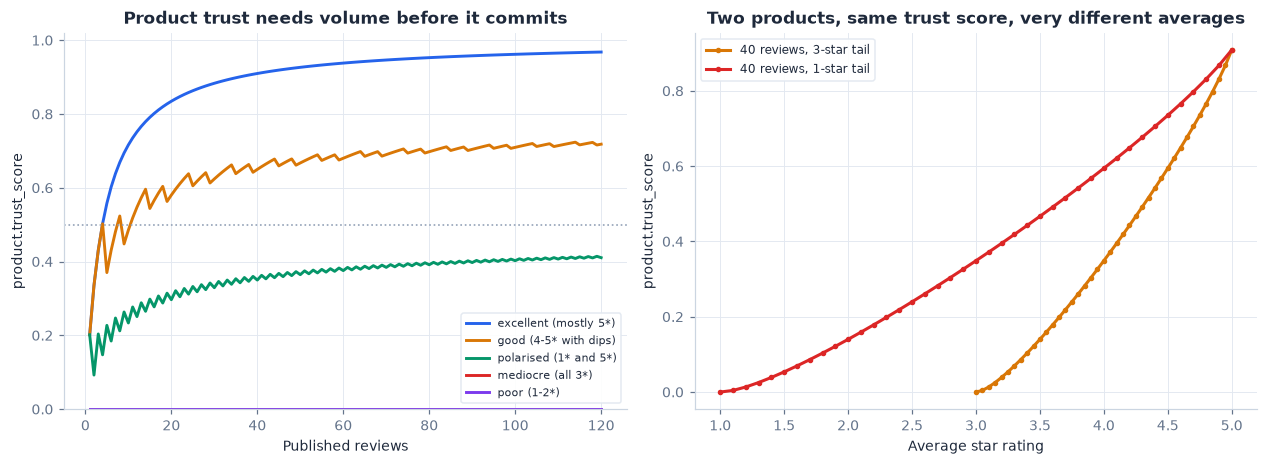


20x5* + 20x3*: avg 4.00, trust 0.3488
20x5* + 20x1*: avg 3.00, trust 0.3488  <- identical trust, 1.0 star lower average

Visibility gate (defaults OFF; config-driven):
  threshold=0.30 min_reviews= 5 -> poor product (trust 0.000, n=10) hidden? True
  threshold=0.50 min_reviews= 5 -> poor product (trust 0.000, n=10) hidden? True
  threshold=0.50 min_reviews=20 -> poor product (trust 0.000, n=10) hidden? False


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.3))

# (a) trust_score vs review count for several star mixes, all reviews fresh.
counts = list(range(1, 121))
for colour, (label, mix) in zip(SERIES, star_mixes.items()):
    series = []
    for n in counts:
        rows = [(mix[i % len(mix)], 2.0) for i in range(n)]
        series.append(product_trust(rows))
    ax1.plot(counts, series, color=colour, lw=1.9, label=label)
ax1.axhline(0.5, color=GREY, ls=":", lw=1.1)
ax1.set_xlabel("Published reviews"); ax1.set_ylabel("product.trust_score")
ax1.set_title("Product trust needs volume before it commits")
ax1.set_ylim(0, 1.02); ax1.grid(True); ax1.legend(fontsize=7.4, loc="lower right")

# (b) The >=4 cut: average stars is NOT monotone with trust_score.
pairs = []
for four_plus in range(0, 41):
    mix = [5] * four_plus + [3] * (40 - four_plus)
    pairs.append((sum(mix) / 40, product_trust([(s, 3.0) for s in mix]), "3-star tail"))
for four_plus in range(0, 41):
    mix = [5] * four_plus + [1] * (40 - four_plus)
    pairs.append((sum(mix) / 40, product_trust([(s, 3.0) for s in mix]), "1-star tail"))
for colour, tail in zip([AMBER, RED], ["3-star tail", "1-star tail"]):
    xs = [p[0] for p in pairs if p[2] == tail]
    ys = [p[1] for p in pairs if p[2] == tail]
    ax2.plot(xs, ys, color=colour, lw=2.0, marker="o", ms=2.6, label="40 reviews, %s" % tail)
ax2.set_xlabel("Average star rating"); ax2.set_ylabel("product.trust_score")
ax2.set_title("Two products, same trust score, very different averages")
ax2.grid(True); ax2.legend(fontsize=8)

fig.tight_layout()
print("saved:", save(fig, "product_trust.png"))
plt.show()

# The identical-trust / different-average pair, stated numerically.
a = [(5, 3.0)] * 20 + [(3, 3.0)] * 20
b = [(5, 3.0)] * 20 + [(1, 3.0)] * 20
print("\n20x5* + 20x3*: avg %.2f, trust %.4f" % (4.0, product_trust(a)))
print("20x5* + 20x1*: avg %.2f, trust %.4f  <- identical trust, 1.0 star lower average"
      % (3.0, product_trust(b)))
print("\nVisibility gate (defaults OFF; config-driven):")
for thr, minr in [(0.30, 5), (0.50, 5), (0.50, 20)]:
    print("  threshold=%.2f min_reviews=%2d -> poor product (trust %.3f, n=10) hidden? %s"
          % (thr, minr, product_trust([(1, 3.0)] * 10),
             product_low_trust(product_trust([(1, 3.0)] * 10), 10,
                               threshold=thr, min_reviews=minr)))

**What this means for the product.** Product trust is intentionally coarse: it answers "would a
buyer be satisfied?" (>= 4 stars), not "how good is this?". Two catalogue entries can share a
trust score of ~0.35 while their average ratings differ by a full star. For an affiliate-review
site this is arguably the right question — the score gates *visibility*, and a 3-star product
and a 1-star product are equally not-recommendable — but the notebook records the trade-off
because the star average shown next to it in the UI will sometimes disagree with it.

Also note `product_low_trust` requires `review_count >= min_reviews`, so a brand-new product with
a single bad review is never suppressed. Both thresholds are configuration and ship **off**.

---
# Part 4 — Commission, contracts, Honesty Fund, payouts

This is the part a defense panel will press hardest on, because it is the part that moves money.
Every function here is exact-decimal (`decimal.Decimal`), never floating point.

## 4.1 The 40/30/30 split — and why the platform absorbs the rounding

**The problem.** Splitting a peso amount three ways will not divide evenly. Rounding each share
independently makes the three shares fail to re-sum to the gross — a leak that, at scale, is
either theft or a reconciliation nightmare.

**The decision** (`earnings.split_commission`): round the reviewer and Honesty Fund shares to the
centavo with `ROUND_HALF_UP`, then compute the platform share as the **remainder**:

```python
platform = gross - reviewer - honesty
```

The platform therefore absorbs the rounding error in both directions, and
`platform + reviewer + honesty == gross` holds exactly, for every input, by construction.

**Tiered variant** (`split_commission_tiered`): the Honesty Fund's 30% is a fixed capstone
invariant; the *reviewer's* share is `reviewer_share_bps / 10000` (standard 3000, founding 3500,
special 4000 — seeded in `backend/scripts/seed.py`), and the guard
`0 <= bps <= MAX_REVIEWER_SHARE_BPS (7000)` exists because above 70% the platform share would go
negative.

In [25]:
print("PLATFORM_SHARE=%s REVIEWER_SHARE=%s HONESTY_FUND_SHARE=%s  (sum %s)"
      % (PLATFORM_SHARE, REVIEWER_SHARE, HONESTY_FUND_SHARE,
         PLATFORM_SHARE + REVIEWER_SHARE + HONESTY_FUND_SHARE))
print("MAX_REVIEWER_SHARE_BPS =", MAX_REVIEWER_SHARE_BPS)
print()
print(inspect.getsource(split_commission))

PLATFORM_SHARE=0.40 REVIEWER_SHARE=0.30 HONESTY_FUND_SHARE=0.30  (sum 1.00)
MAX_REVIEWER_SHARE_BPS = 7000

def split_commission(gross: Decimal) -> dict[str, Decimal]:
    """Split `gross` 40/30/30. Reviewer & Honesty Fund are rounded to the centavo;
    the platform share takes the remainder so the three always sum to `gross`.
    """
    gross = Decimal(gross).quantize(_CENT, rounding=ROUND_HALF_UP)
    reviewer = (gross * REVIEWER_SHARE).quantize(_CENT, rounding=ROUND_HALF_UP)
    honesty = (gross * HONESTY_FUND_SHARE).quantize(_CENT, rounding=ROUND_HALF_UP)
    platform = gross - reviewer - honesty
    return {
        "gross_amount": gross,
        "platform_share": platform,
        "reviewer_share": reviewer,
        "honesty_fund_share": honesty,
    }



In [26]:
# Exhaustive-ish conservation proof over 200,001 gross amounts and every seeded tier.
TIERS = {"standard": 3000, "founding": 3500, "special": 4000}

violations = 0
remainders = {name: [] for name in TIERS}
checked = 0
for cents in range(1, 200_002):                     # PHP 0.01 .. 2000.01
    gross = Decimal(cents) / Decimal(100)
    for name, bps in TIERS.items():
        s = split_commission_tiered(gross, bps)
        total = s["platform_share"] + s["reviewer_share"] + s["honesty_fund_share"]
        if total != s["gross_amount"]:
            violations += 1
        exact_platform = (s["gross_amount"] * (Decimal(10000 - bps) / Decimal(10000)
                                               - HONESTY_FUND_SHARE))
        remainders[name].append(float(s["platform_share"] - exact_platform))
        checked += 1

print("checked %d splits across %d tiers" % (checked, len(TIERS)))
print("conservation violations (platform + reviewer + honesty != gross):", violations)
assert violations == 0, "commission split leaks value"
for name in TIERS:
    r = remainders[name]
    print("  %-9s platform rounding remainder: min %+.4f  max %+.4f  mean %+.6f PHP"
          % (name, min(r), max(r), sum(r) / len(r)))

checked 600003 splits across 3 tiers
conservation violations (platform + reviewer + honesty != gross): 0
  standard  platform rounding remainder: min -0.0100  max +0.0080  mean -0.001000 PHP
  founding  platform rounding remainder: min -0.0075  max +0.0070  mean -0.000750 PHP
  special   platform rounding remainder: min -0.0070  max +0.0070  mean -0.000500 PHP


saved: docs/assets/notebooks/commission_split.png


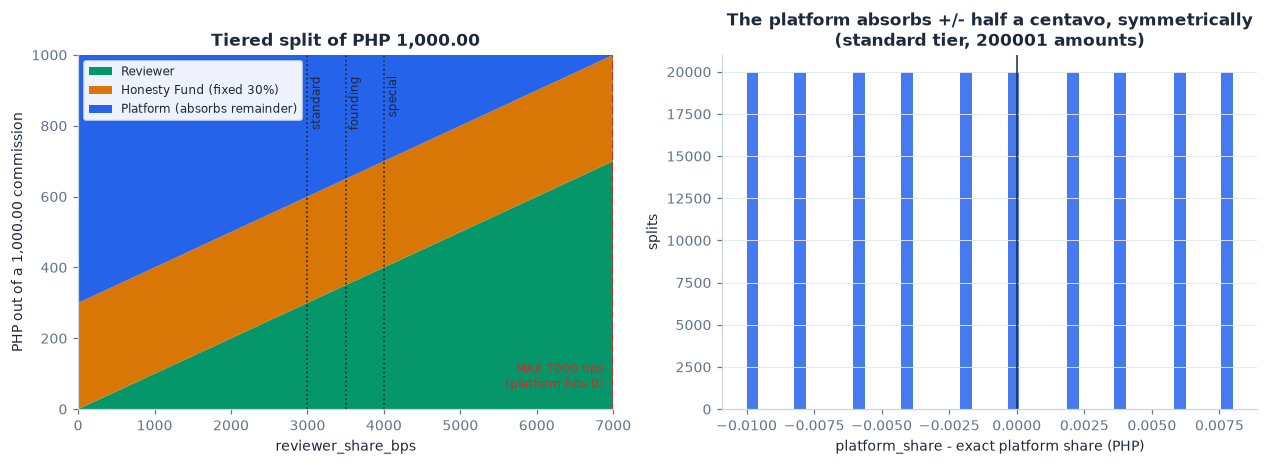


Worked example, PHP 1,234.57 gross:
  standard  reviewer   370.37  honesty   370.37  platform   493.83  sum 1234.57
  founding  reviewer   432.10  honesty   370.37  platform   432.10  sum 1234.57
  special   reviewer   493.83  honesty   370.37  platform   370.37  sum 1234.57


In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.3))

# (a) Where the money goes as the reviewer's bps rises.
bps_axis = list(range(0, MAX_REVIEWER_SHARE_BPS + 1, 50))
gross = Decimal("1000.00")
rev, hon, plat = [], [], []
for bps in bps_axis:
    s = split_commission_tiered(gross, bps)
    rev.append(float(s["reviewer_share"]))
    hon.append(float(s["honesty_fund_share"]))
    plat.append(float(s["platform_share"]))
ax1.stackplot(bps_axis, rev, hon, plat, colors=[GREEN, AMBER, BLUE],
              labels=["Reviewer", "Honesty Fund (fixed 30%)", "Platform (absorbs remainder)"])
for name, bps in TIERS.items():
    ax1.axvline(bps, color=INK, ls=":", lw=1.1)
    ax1.text(bps + 30, 940, name, fontsize=7.6, color=INK, rotation=90, va="top")
ax1.axvline(MAX_REVIEWER_SHARE_BPS, color=RED, ls="--", lw=1.4)
ax1.text(MAX_REVIEWER_SHARE_BPS - 120, 60, "MAX 7000 bps\n(platform hits 0)", fontsize=7.6,
         color=RED, ha="right")
ax1.set_xlabel("reviewer_share_bps"); ax1.set_ylabel("PHP out of a 1,000.00 commission")
ax1.set_title("Tiered split of PHP 1,000.00")
ax1.set_xlim(0, MAX_REVIEWER_SHARE_BPS); ax1.set_ylim(0, 1000)
ax1.legend(fontsize=7.6, loc="upper left")

# (b) Rounding remainder distribution, standard tier.
ax2.hist(remainders["standard"], bins=41, color=BLUE, alpha=0.85)
ax2.axvline(0, color=INK, lw=1.0)
ax2.set_xlabel("platform_share - exact platform share (PHP)")
ax2.set_ylabel("splits")
ax2.set_title("The platform absorbs +/- half a centavo, symmetrically\n(standard tier, %d amounts)"
              % len(remainders["standard"]))
ax2.grid(True, axis="y")

fig.tight_layout()
print("saved:", save(fig, "commission_split.png"))
plt.show()

print("\nWorked example, PHP 1,234.57 gross:")
for name, bps in TIERS.items():
    s = split_commission_tiered(Decimal("1234.57"), bps)
    print("  %-9s reviewer %8s  honesty %8s  platform %8s  sum %s"
          % (name, s["reviewer_share"], s["honesty_fund_share"], s["platform_share"],
             s["platform_share"] + s["reviewer_share"] + s["honesty_fund_share"]))

**What this means for the product.** The invariant `shares sum to gross` is not a test that
happens to pass — it is structural, because one of the three shares is defined as a subtraction.
The cost is that the platform's take is not exactly 40%: it is 40% ± half a centavo per
commission, symmetric around zero and therefore unbiased at scale. That is a defensible design
and it is stated openly here.

## 4.2 The contract gate on the reviewer's share

**The decision** (`contract_service.reviewer_bps_for_review`): every monetised review runs a
revenue-share contract with a term (default 6 months, auto-renewing). At reconciliation:

- contract `active` -> reviewer earns their **tier bps**
- contract `expired` / `bought_out` / **absent** -> reviewer earns **0 bps**

The Honesty Fund's 30% is untouched in every case; the reviewer's forgone share goes to the
platform. This is a single `if` in one function, and it is the only economic effect a contract has.

status       tier        eff. bps     reviewer      honesty     platform
active       standard        3000      1500.00      1500.00      2000.00
active       founding        3500      1750.00      1500.00      1750.00
active       special         4000      2000.00      1500.00      1500.00
expired      standard           0         0.00      1500.00      3500.00
expired      founding           0         0.00      1500.00      3500.00
expired      special            0         0.00      1500.00      3500.00
bought_out   standard           0         0.00      1500.00      3500.00
bought_out   founding           0         0.00      1500.00      3500.00
bought_out   special            0         0.00      1500.00      3500.00
no contract  standard           0         0.00      1500.00      3500.00
no contract  founding           0         0.00      1500.00      3500.00
no contract  special            0         0.00      1500.00      3500.00



saved: docs/assets/notebooks/contract_gate.png


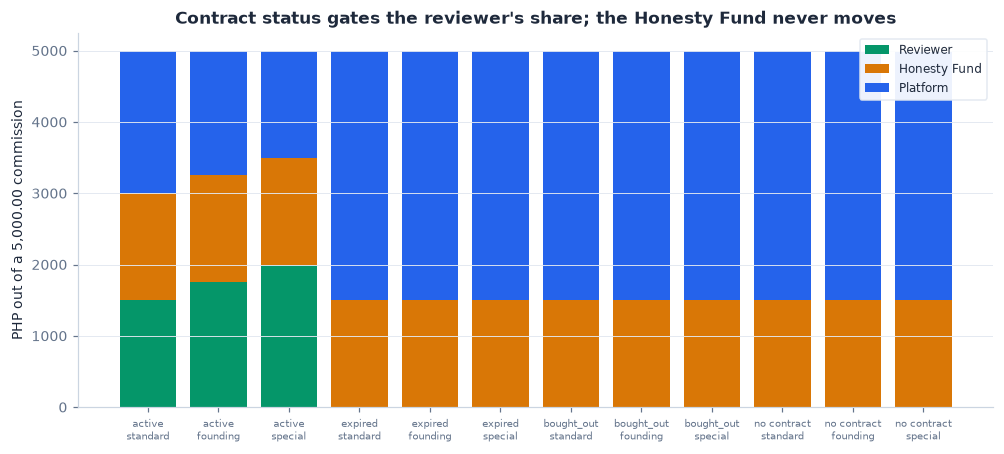

In [28]:
# The gate, exactly as reviewer_bps_for_review resolves it (DB lookup elided).
STATUSES = ["active", "expired", "bought_out", "no contract"]
gross = Decimal("5000.00")

print("%-12s %-9s %10s %12s %12s %12s"
      % ("status", "tier", "eff. bps", "reviewer", "honesty", "platform"))
rows = []
for status in STATUSES:
    for name, bps in TIERS.items():
        eff = bps if status == "active" else 0
        s = split_commission_tiered(gross, eff)
        rows.append((status, name, eff, s))
        print("%-12s %-9s %10d %12s %12s %12s"
              % (status, name, eff, s["reviewer_share"], s["honesty_fund_share"],
                 s["platform_share"]))

fig, ax = plt.subplots(figsize=(9.2, 4.2))
labels = ["%s\n%s" % (st, tn) for st, tn, _, _ in rows]
reviewer = [float(s["reviewer_share"]) for _, _, _, s in rows]
honesty = [float(s["honesty_fund_share"]) for _, _, _, s in rows]
platform = [float(s["platform_share"]) for _, _, _, s in rows]
x = range(len(rows))
ax.bar(x, reviewer, color=GREEN, label="Reviewer")
ax.bar(x, honesty, bottom=reviewer, color=AMBER, label="Honesty Fund")
ax.bar(x, platform, bottom=[r + h for r, h in zip(reviewer, honesty)], color=BLUE, label="Platform")
ax.set_xticks(list(x)); ax.set_xticklabels(labels, fontsize=6.8)
ax.set_ylabel("PHP out of a 5,000.00 commission")
ax.set_title("Contract status gates the reviewer's share; the Honesty Fund never moves")
ax.legend(fontsize=8); ax.grid(True, axis="y")
fig.tight_layout()
print("\nsaved:", save(fig, "contract_gate.png"))
plt.show()

## 4.3 The Honesty Fund — paying for honest negative reviews

**The problem.** Every affiliate incentive pushes a reviewer toward positive reviews, because
only a positive review earns a click-through. A platform whose thesis is *structural incentive
alignment* has to pay for the negative case too, or the incentive is a lie.

**The decision** (FR-6). Reviews of **<= 2 stars** cannot carry an affiliate link
(`referral_service.attach_affiliate_link` rejects them) and are routed to
`earn_eligible_status = honesty_fund` on publication. Once a month, the pooled 30% Honesty-Fund
share of that cycle's commissions is distributed among those reviews in proportion to an
**Honesty Score**.

**Honesty Score** (`trust.honesty_score`, `honesty_fund_service._review_score`):

$$
\mathrm{score}_i \;=\; \Big(\textstyle\sum_{v \,\in\, \text{up-voters}} \mathrm{gate\_vote\_weight}(v)\Big)
\;\times\; \mathrm{price\_multiplier}(\text{price\_paid}_i)
$$

Price multiplier (`constants.honesty_price_multiplier`): **1.0x** below PHP 500, **1.5x** for
500-1,499, **2.0x** for 1,500+.

**Distribution** (`honesty_fund_service.distribute`):

$$
\mathrm{payout}_i \;=\; \Big\lfloor\, \mathrm{pool} \times \frac{\mathrm{score}_i}{\sum_j \mathrm{score}_j} \,\Big\rfloor_{\text{centavo}}
$$

`ROUND_FLOOR`, so the dust remainder stays with the pool. Reviews scoring 0 (no up-votes, or only
zero-weight voters) are dropped before the proportion is taken. The whole run is idempotent per
cycle: if any distribution row exists for the cycle it aborts rather than paying twice.

In [29]:
print(inspect.getsource(honesty_price_multiplier))
print(inspect.getsource(honesty_score))

for price in ["0", "1", "499.99", "500", "1499.99", "1500", "25000"]:
    print("  price PHP %-9s -> multiplier %s" % (price, honesty_price_multiplier(Decimal(price))))

def honesty_price_multiplier(price_php: Decimal) -> Decimal:
    """1.0x below 500; 1.5x 500–1,499; 2.0x 1,500+."""
    if price_php >= Decimal("1500"):
        return Decimal("2.0")
    if price_php >= Decimal("500"):
        return Decimal("1.5")
    return Decimal("1.0")

def honesty_score(trust_weighted_helpful_votes: Decimal, price_php: Decimal) -> Decimal:
    """Honesty Score = trust-weighted helpfulness votes x price-bracket multiplier (FR-6)."""
    return Decimal(trust_weighted_helpful_votes) * honesty_price_multiplier(Decimal(price_php))

  price PHP 0         -> multiplier 1.0
  price PHP 1         -> multiplier 1.0
  price PHP 499.99    -> multiplier 1.0
  price PHP 500       -> multiplier 1.5
  price PHP 1499.99   -> multiplier 1.5
  price PHP 1500      -> multiplier 2.0
  price PHP 25000     -> multiplier 2.0


In [30]:
# Full distribution simulation, mirroring honesty_fund_service.distribute exactly.
CENT = Decimal("0.01")

@dataclass
class Voter:
    stage: int
    reputation: float
    account_age_days: int
    probation: bool = False


def review_honesty_score(voters, price_php):
    # Mirror of honesty_fund_service._review_score (lines 49-65).
    weighted = Decimal("0")
    for v in voters:
        weighted += Decimal(str(gate_vote_weight(v.stage, v.reputation,
                                                 v.account_age_days, v.probation)))
    return honesty_score(weighted, Decimal(price_php))


def distribute(pool: Decimal, scored):
    # Mirror of honesty_fund_service.distribute (lines 68-127), money math only.
    pool = Decimal(pool).quantize(CENT)
    scored = [(name, s) for name, s in scored if s > 0]
    total = sum(s for _, s in scored)
    if not scored or total <= 0 or pool <= 0:
        return [], pool
    payouts = [(name, (pool * s / total).quantize(CENT, rounding=ROUND_FLOOR))
               for name, s in scored]
    dust = pool - sum(p for _, p in payouts)
    return payouts, dust


rng = random.Random(2026)

def make_voters(n, quality):
    # quality in 0..1 drives stage and reputation of the up-voters.
    out = []
    for _ in range(n):
        stage = min(5, max(1, int(rng.gauss(1 + 4 * quality, 0.8))))
        rep = min(100.0, max(10.0, rng.gauss(40 + 55 * quality, 8)))
        age = rng.choice([5, 12, 45, 200, 400, 900])
        out.append(Voter(stage, rep, age))
    return out


CATALOG = [
    ("cheap gadget, ignored",       3,  0.25, "349.00"),
    ("cheap gadget, popular",      22,  0.45, "429.00"),
    ("mid-range, well received",   14,  0.70, "980.00"),
    ("mid-range, expert-backed",    9,  0.95, "1250.00"),
    ("expensive, viral warning",   38,  0.60, "7400.00"),
    ("expensive, few but trusted",  6,  0.95, "18990.00"),
    ("no up-votes at all",          0,  0.00, "2500.00"),
]

scored = []
detail = []
for name, n_voters, quality, price in CATALOG:
    voters = make_voters(n_voters, quality)
    s = review_honesty_score(voters, price)
    scored.append((name, s))
    detail.append((name, n_voters, price, honesty_price_multiplier(Decimal(price)),
                   sum(Decimal(str(gate_vote_weight(v.stage, v.reputation, v.account_age_days,
                                                    v.probation))) for v in voters), s))

POOL = Decimal("42750.00")     # 30% of a month of commissions
payouts, dust = distribute(POOL, scored)

print("Honesty Fund cycle — pool PHP %s\n" % POOL)
print("%-30s %7s %10s %6s %12s %12s %12s"
      % ("review", "voters", "price", "mult", "raw weight", "score", "payout"))
paid = dict(payouts)
for name, n, price, mult, raw, s in detail:
    print("%-30s %7d %10s %6s %12.4f %12.4f %12s"
          % (name, n, price, mult, raw, s, paid.get(name, Decimal("0.00"))))
print("\ntotal paid PHP %s   dust retained by the pool PHP %s"
      % (sum(p for _, p in payouts), dust))
assert sum(p for _, p in payouts) + dust == POOL
print("conservation: sum(payouts) + dust == pool  ->  OK")

Honesty Fund cycle — pool PHP 42750.00

review                          voters      price   mult   raw weight        score       payout
cheap gadget, ignored                3     349.00    1.0       1.1959       1.1959       369.92
cheap gadget, popular               22     429.00    1.0      14.2851      14.2851      4418.79
mid-range, well received            14     980.00    1.5      14.6208      21.9312      6783.97
mid-range, expert-backed             9    1250.00    1.5      15.8554      23.7831      7356.83
expensive, viral warning            38    7400.00    2.0      29.4578      58.9157     18224.36
expensive, few but trusted           6   18990.00    2.0       9.0455      18.0911      5596.11
no up-votes at all                   0    2500.00    2.0       0.0000       0.0000         0.00

total paid PHP 42749.98   dust retained by the pool PHP 0.02
conservation: sum(payouts) + dust == pool  ->  OK


saved: docs/assets/notebooks/honesty_fund.png


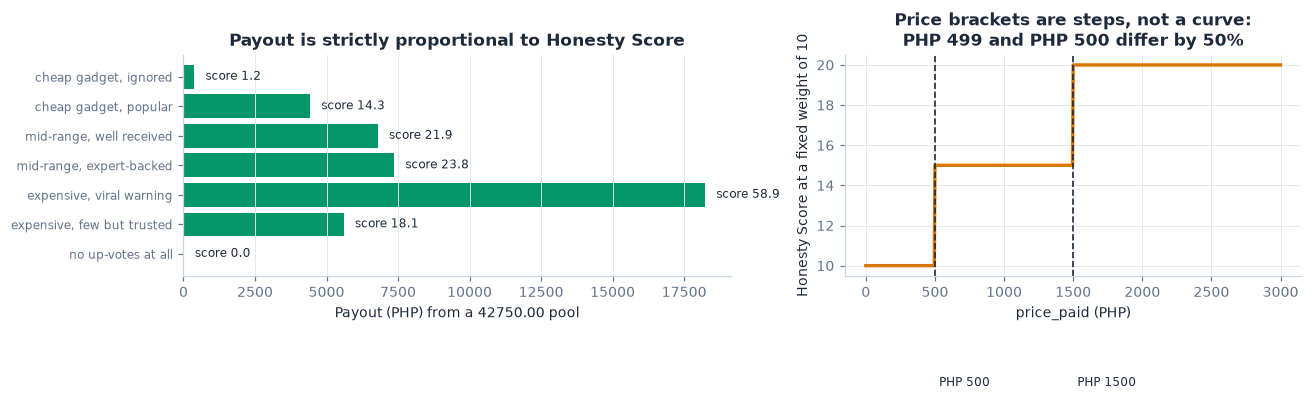

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 4.4),
                               gridspec_kw={"width_ratios": [1.2, 1]})

names = [d[0] for d in detail]
vals = [float(paid.get(n, Decimal("0"))) for n in names]
scores = [float(d[5]) for d in detail]
colours = [GREY if v == 0 else GREEN for v in vals]
ax1.barh(range(len(names)), vals, color=colours)
ax1.set_yticks(range(len(names))); ax1.set_yticklabels(names, fontsize=8)
ax1.invert_yaxis()
for i, (v, s) in enumerate(zip(vals, scores)):
    ax1.text(v + POOL_X if False else v + 400, i, "score %.1f" % s, va="center",
             fontsize=7.6, color=INK)
ax1.set_xlabel("Payout (PHP) from a %s pool" % POOL)
ax1.set_title("Payout is strictly proportional to Honesty Score")
ax1.grid(True, axis="x")

# Price multiplier is a step function — show the discontinuity it creates.
prices = [p for p in range(0, 3001, 5)]
weight = Decimal("10")
ax2.plot(prices, [float(honesty_score(weight, Decimal(p))) for p in prices],
         color=AMBER, lw=2.2)
for edge in [500, 1500]:
    ax2.axvline(edge, color=INK, ls="--", lw=1.1)
    ax2.text(edge + 30, 4, "PHP %d" % edge, fontsize=8, color=INK)
ax2.set_xlabel("price_paid (PHP)"); ax2.set_ylabel("Honesty Score at a fixed weight of 10")
ax2.set_title("Price brackets are steps, not a curve:\nPHP 499 and PHP 500 differ by 50%")
ax2.grid(True)

fig.tight_layout()
print("saved:", save(fig, "honesty_fund.png"))
plt.show()

saved: docs/assets/notebooks/honesty_fund_weighting.png


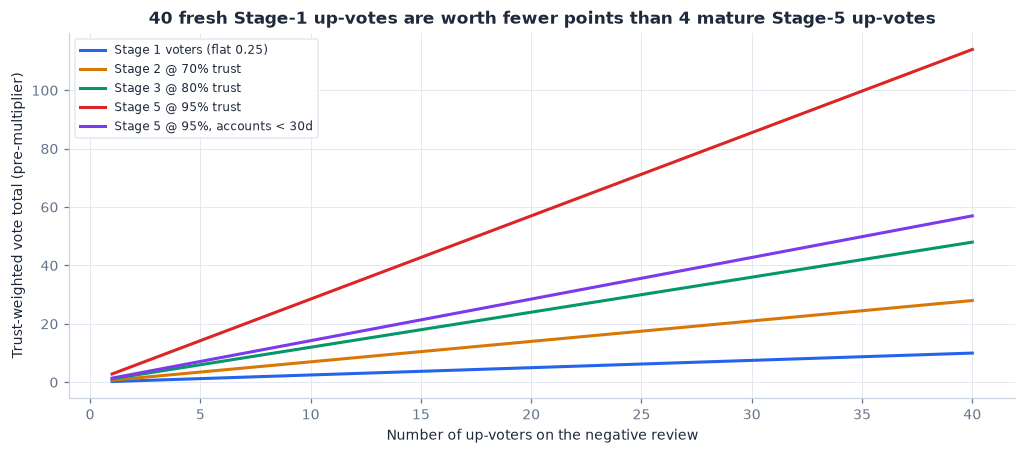

40 Stage-1 votes  = 10.000 weighted
 4 Stage-5 votes  = 11.400 weighted  -> Stage-5 wins
Votes of Stage-1 needed to match 4 Stage-5 votes: 45.6


In [32]:
# Sensitivity: how much does voter quality (not vote count) move the payout?
fig, ax = plt.subplots(figsize=(9.4, 4.2))

vote_counts = list(range(1, 41))
for colour, (label, stage, rep, age) in zip(SERIES, [
        ("Stage 1 voters (flat 0.25)", 1, 20.0, 400),
        ("Stage 2 @ 70% trust", 2, 70.0, 400),
        ("Stage 3 @ 80% trust", 3, 80.0, 400),
        ("Stage 5 @ 95% trust", 5, 95.0, 400),
        ("Stage 5 @ 95%, accounts < 30d", 5, 95.0, 10)]):
    w = gate_vote_weight(stage, rep, age, False)
    ax.plot(vote_counts, [n * w for n in vote_counts], color=colour, lw=2.0, label=label)
ax.set_xlabel("Number of up-voters on the negative review")
ax.set_ylabel("Trust-weighted vote total (pre-multiplier)")
ax.set_title("40 fresh Stage-1 up-votes are worth fewer points than 4 mature Stage-5 up-votes")
ax.grid(True); ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
print("saved:", save(fig, "honesty_fund_weighting.png"))
plt.show()

w1 = gate_vote_weight(1, 20.0, 400, False)
w5 = gate_vote_weight(5, 95.0, 400, False)
print("40 Stage-1 votes  = %.3f weighted" % (40 * w1))
print(" 4 Stage-5 votes  = %.3f weighted  -> %s"
      % (4 * w5, "Stage-5 wins" if 4 * w5 > 40 * w1 else "Stage-1 volume wins"))
print("Votes of Stage-1 needed to match 4 Stage-5 votes: %.1f" % (4 * w5 / w1))

**What this means for the product.** The Honesty Fund converts community approval of *negative*
reviews directly into money, and it does so with trust-weighted votes rather than raw counts, so
the cheapest attack (mass-registering accounts to up-vote your own 1-star review) buys almost
nothing: Stage-1 accounts contribute 0.25 each, and brand-new accounts contribute 0.125.

Two honest caveats recorded here:

1. **The price bracket is a cliff, not a ramp.** A PHP 499 purchase scores 1.0x and a PHP 500
   purchase scores 1.5x — a 50% jump across one peso. Nothing in the code smooths it.
2. **Zero-score reviews are silently dropped**, so a genuine negative review that nobody voted on
   receives nothing at all and does not even appear in the distribution rows.

## 4.4 Payout scheduling — tier priority and the wallet-reservation invariant

**The problem.** Paying out a wallet balance is a two-phase operation (schedule, then the provider
settles). If the wallet is debited only on settlement, the same balance can be scheduled twice.

**The decision** (`payout_service`): the wallet is debited **when the payout is scheduled**, not
when it is paid. `failed` and `cancelled` refund it. The invariant maintained is

```
wallet == inflows - SUM(payouts in scheduled/processing/paid)
```

**Scheduling order** is the "payment scheduling by membership tier" requirement: candidates are
sorted by `(membership_tiers.payout_priority, -wallet_balance)` — special (1), founding (2),
standard (3), largest balance first inside a tier. Eligibility is
`wallet_balance >= PAYOUT_MIN_PHP` **and** a payout account on file.

In [33]:
PAYOUT_PRIORITY = {"special": 1, "founding": 2, "standard": 3}
MIN_PHP = Decimal("300.00")     # settings.payout_min_php; constants.PAYOUT_MINIMUM_PHP agrees
print("PAYOUT_MINIMUM_PHP (constants) =", PAYOUT_MINIMUM_PHP)

@dataclass
class Member:
    name: str
    tier: str
    wallet: Decimal
    has_account: bool


def schedule(members):
    # Mirror of payout_service.schedule_payouts ordering + reservation (lines 64-127).
    candidates = [m for m in members if m.wallet >= MIN_PHP]
    candidates.sort(key=lambda m: (PAYOUT_PRIORITY.get(m.tier, 999), -m.wallet))
    created, skipped_no_account = [], 0
    for m in candidates:
        if not m.has_account:
            skipped_no_account += 1
            continue
        amount = Decimal(m.wallet).quantize(CENT)
        m.wallet -= amount                      # reserved immediately
        created.append((m.name, m.tier, amount))
    return created, skipped_no_account


rng = random.Random(11)
members = [
    Member("ana (special)",      "special",  Decimal("350.00"), True),
    Member("ben (special)",      "special",  Decimal("1200.00"), True),
    Member("cara (founding)",    "founding", Decimal("400.00"), True),
    Member("dino (founding)",    "founding", Decimal("980.50"), True),
    Member("elle (standard)",    "standard", Decimal("5000.00"), True),
    Member("fritz (standard)",   "standard", Decimal("310.25"), True),
    Member("gina (standard)",    "standard", Decimal("299.99"), True),   # below minimum
    Member("hugo (standard)",    "standard", Decimal("2500.00"), False), # no payout account
]
inflows = {m.name: m.wallet for m in members}

created, skipped = schedule(members)
print("\nBatch order (payout_priority, then largest balance):")
for i, (name, tier, amount) in enumerate(created, 1):
    print("  %d. %-18s %-9s PHP %10s" % (i, name, tier, amount))
print("\nskipped (no payout account):", skipped)
print("skipped (below PHP %s minimum): %d" % (MIN_PHP,
      sum(1 for m in members if inflows[m.name] < MIN_PHP)))

reserved = {n: a for n, _, a in created}
print("\nInvariant wallet == inflows - reserved:")
ok = True
for m in members:
    expect = inflows[m.name] - reserved.get(m.name, Decimal("0.00"))
    ok &= (m.wallet == expect)
    print("  %-18s wallet %10s  expected %10s  %s"
          % (m.name, m.wallet, expect, "OK" if m.wallet == expect else "MISMATCH"))
assert ok

PAYOUT_MINIMUM_PHP (constants) = 300.00

Batch order (payout_priority, then largest balance):
  1. ben (special)      special   PHP    1200.00
  2. ana (special)      special   PHP     350.00
  3. dino (founding)    founding  PHP     980.50
  4. cara (founding)    founding  PHP     400.00
  5. elle (standard)    standard  PHP    5000.00
  6. fritz (standard)   standard  PHP     310.25

skipped (no payout account): 1
skipped (below PHP 300.00 minimum): 1

Invariant wallet == inflows - reserved:
  ana (special)      wallet       0.00  expected       0.00  OK
  ben (special)      wallet       0.00  expected       0.00  OK
  cara (founding)    wallet       0.00  expected       0.00  OK
  dino (founding)    wallet       0.00  expected       0.00  OK
  elle (standard)    wallet       0.00  expected       0.00  OK
  fritz (standard)   wallet       0.00  expected       0.00  OK
  gina (standard)    wallet     299.99  expected     299.99  OK
  hugo (standard)    wallet    2500.00  expected    2

saved: docs/assets/notebooks/payout_lifecycle.png


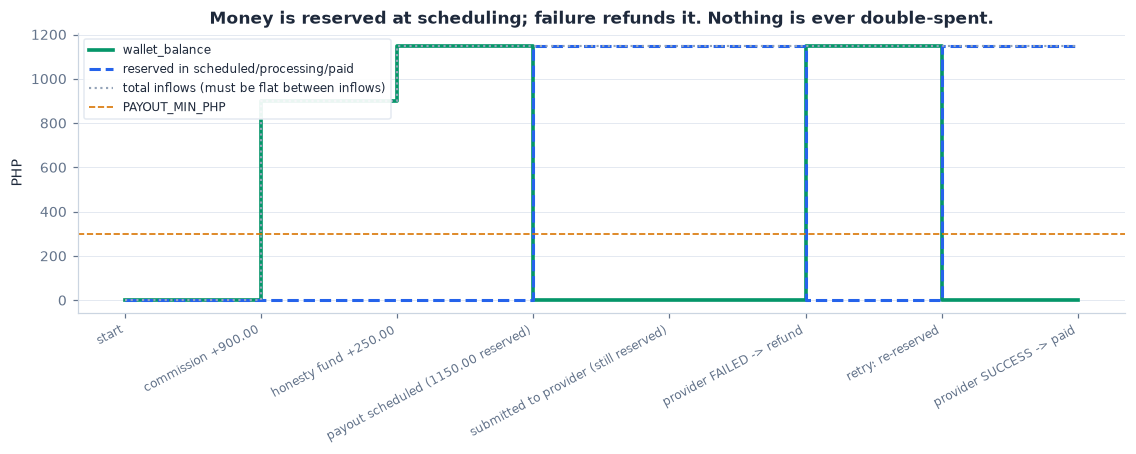

In [34]:
# Lifecycle: schedule -> fail -> retry -> pay, tracking the invariant at every step.
timeline = []
wallet = Decimal("0.00")
inflow_total = Decimal("0.00")
reserved_total = Decimal("0.00")

def step(label, d_inflow=Decimal("0"), d_reserved=Decimal("0")):
    global wallet, inflow_total, reserved_total
    inflow_total += d_inflow
    reserved_total += d_reserved
    wallet = inflow_total - reserved_total
    timeline.append((label, float(wallet), float(reserved_total)))

step("start")
step("commission +900.00", d_inflow=Decimal("900.00"))
step("honesty fund +250.00", d_inflow=Decimal("250.00"))
step("payout scheduled (1150.00 reserved)", d_reserved=Decimal("1150.00"))
step("submitted to provider (still reserved)")
step("provider FAILED -> refund", d_reserved=Decimal("-1150.00"))
step("retry: re-reserved", d_reserved=Decimal("1150.00"))
step("provider SUCCESS -> paid")

fig, ax = plt.subplots(figsize=(10.4, 4.2))
labels = [t[0] for t in timeline]
xs = range(len(timeline))
ax.step(xs, [t[1] for t in timeline], where="post", color=GREEN, lw=2.4, label="wallet_balance")
ax.step(xs, [t[2] for t in timeline], where="post", color=BLUE, lw=2.0, ls="--",
        label="reserved in scheduled/processing/paid")
ax.step(xs, [t[1] + t[2] for t in timeline], where="post", color=GREY, lw=1.4, ls=":",
        label="total inflows (must be flat between inflows)")
ax.axhline(float(MIN_PHP), color=AMBER, ls="--", lw=1.1, label="PAYOUT_MIN_PHP")
ax.set_xticks(list(xs)); ax.set_xticklabels(labels, rotation=28, ha="right", fontsize=7.6)
ax.set_ylabel("PHP")
ax.set_title("Money is reserved at scheduling; failure refunds it. Nothing is ever double-spent.")
ax.grid(True, axis="y"); ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
print("saved:", save(fig, "payout_lifecycle.png"))
plt.show()

---
# Part 5 — Security algorithms

## 5.1 Argon2id password hashing (ADR-011, supersedes ADR-008)

**The problem.** The source specification had a `password_hash` column and named no KDF. A fast
hash (SHA-256, MD5) makes a stolen database trivially crackable at billions of guesses per second
on commodity GPUs.

**The decision.** `argon2-cffi`'s `PasswordHasher` with library defaults — **Argon2id**, the
current OWASP-recommended password KDF. Argon2id is *memory-hard*: an attacker must allocate
64 MiB per parallel guess, which is what collapses GPU and ASIC throughput. `check_needs_rehash`
lets parameters be raised later without a forced password reset.

The parameters below are read from the live hasher object, not from documentation.

In [35]:
from app.core.security import _ph, create_access_token, hash_password, needs_rehash, verify_password

print("hash_password    ->", cite(hash_password))
print("Argon2 variant   :", _ph.type)
print("time_cost   (t)  :", _ph.time_cost, "passes")
print("memory_cost (m)  :", _ph.memory_cost, "KiB = %.0f MiB" % (_ph.memory_cost / 1024))
print("parallelism (p)  :", _ph.parallelism, "lanes")
print("salt / hash len  :", _ph.salt_len, "/", _ph.hash_len, "bytes")

sample = hash_password("correct horse battery staple")
print("\nencoded hash     :", sample[:52] + "...")
print("verify (correct) :", verify_password("correct horse battery staple", sample))
print("verify (wrong)   :", verify_password("Correct Horse Battery Staple", sample))
print("verify (garbage) :", verify_password("x", "not-a-hash"))
print("needs_rehash     :", needs_rehash(sample))

# Salt uniqueness: the same password never produces the same hash.
h1, h2 = hash_password("hunter2"), hash_password("hunter2")
print("same password, two hashes identical?", h1 == h2, "(must be False - random salt)")

hash_password    -> backend/app/core/security.py:40
Argon2 variant   : Type.ID
time_cost   (t)  : 3 passes
memory_cost (m)  : 65536 KiB = 64 MiB
parallelism (p)  : 4 lanes
salt / hash len  : 16 / 32 bytes

encoded hash     : $argon2id$v=19$m=65536,t=3,p=4$dvXwHKmbw8XukKS77jqbz...


verify (correct) : True
verify (wrong)   : False
verify (garbage) : False
needs_rehash     : False


same password, two hashes identical? False (must be False - random salt)


measured hash   : 132.6 ms
measured verify : 118.0 ms
single-core guess rate against this KDF: 8.5 guesses/second


saved: docs/assets/notebooks/argon2id.png


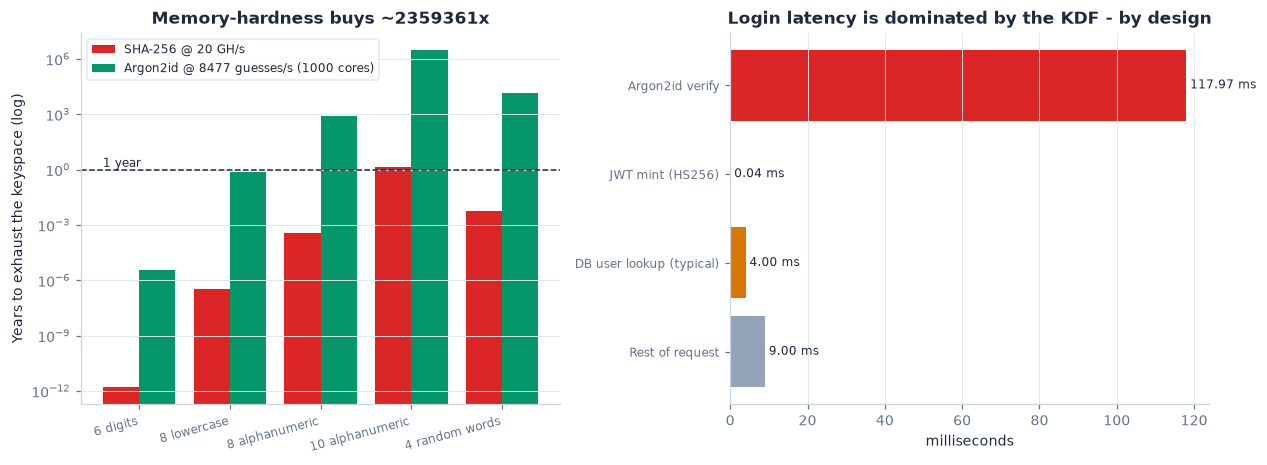


JWT mint measured: 0.041 ms (HS256) - ~2851x cheaper than the KDF


In [36]:
# Measured cost on this machine.
N = 12
t0 = time.perf_counter()
for _ in range(N):
    hash_password("benchmark-password-%d" % random.random())
hash_ms = (time.perf_counter() - t0) / N * 1000

h = hash_password("benchmark")
t0 = time.perf_counter()
for _ in range(N):
    verify_password("benchmark", h)
verify_ms = (time.perf_counter() - t0) / N * 1000

print("measured hash   : %.1f ms" % hash_ms)
print("measured verify : %.1f ms" % verify_ms)
print("single-core guess rate against this KDF: %.1f guesses/second" % (1000 / verify_ms))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.3))

# (a) Time to exhaust a keyspace, Argon2id vs a fast hash. Log scale, order-of-magnitude only.
argon_rate = 1000 / verify_ms * 1000        # optimistic: 1000 parallel cores for the attacker
sha_rate = 20e9                             # ~20 GH/s, a single modern GPU on SHA-256
charsets = [("6 digits", 10 ** 6), ("8 lowercase", 26 ** 8),
            ("8 alphanumeric", 62 ** 8), ("10 alphanumeric", 62 ** 10),
            ("4 random words", 7776 ** 4)]
names = [c[0] for c in charsets]
argon_years = [c[1] / argon_rate / 31_557_600 for c in charsets]
sha_years = [c[1] / sha_rate / 31_557_600 for c in charsets]
x = range(len(charsets))
ax1.bar([i - 0.2 for i in x], sha_years, width=0.4, color=RED, label="SHA-256 @ 20 GH/s")
ax1.bar([i + 0.2 for i in x], argon_years, width=0.4, color=GREEN,
        label="Argon2id @ %.0f guesses/s (1000 cores)" % argon_rate)
ax1.set_yscale("log")
ax1.axhline(1, color=INK, ls="--", lw=1.0)
ax1.text(-0.4, 1.4, "1 year", fontsize=8, color=INK)
ax1.set_xticks(list(x)); ax1.set_xticklabels(names, fontsize=7.6, rotation=15, ha="right")
ax1.set_ylabel("Years to exhaust the keyspace (log)")
ax1.set_title("Memory-hardness buys ~%.0fx" % (sha_rate / argon_rate))
ax1.grid(True, axis="y", which="both"); ax1.legend(fontsize=7.6, loc="upper left")

# (b) Latency budget: where the 60ms sits relative to the request.
components = ["Argon2id verify", "JWT mint (HS256)", "DB user lookup (typical)", "Rest of request"]
t0 = time.perf_counter()
for _ in range(200):
    create_access_token(__import__("uuid").uuid4(), "user")
jwt_ms = (time.perf_counter() - t0) / 200 * 1000
budget = [verify_ms, jwt_ms, 4.0, 9.0]
ax2.barh(range(len(components)), budget, color=[RED, BLUE, AMBER, GREY])
ax2.set_yticks(range(len(components))); ax2.set_yticklabels(components, fontsize=8)
ax2.invert_yaxis()
for i, v in enumerate(budget):
    ax2.text(v + 1, i, "%.2f ms" % v, va="center", fontsize=8, color=INK)
ax2.set_xlabel("milliseconds")
ax2.set_title("Login latency is dominated by the KDF - by design")
ax2.grid(True, axis="x")

fig.tight_layout()
print("saved:", save(fig, "argon2id.png"))
plt.show()
print("\nJWT mint measured: %.3f ms (HS256) - ~%.0fx cheaper than the KDF"
      % (jwt_ms, verify_ms / jwt_ms))

**What this means for the product.** The tens of milliseconds measured above are not overhead, they
are the mechanism: the delay costs a legitimate user nothing perceptible on a once-per-session login,
and it costs an attacker holding a stolen database several orders of magnitude in guess rate
(the measured figure is printed above, not asserted here). The trade-off is that login is *not* a cheap endpoint,
which is exactly why it is rate-limited (§5.2) — the KDF also makes the auth endpoint a plausible
CPU-exhaustion target if it were left open.

## 5.2 Fixed-window rate limiting (ADR-009)

**The problem.** The source specification had no rate limiting at all, leaving registration and
auth open to flooding — and, given §5.1, to CPU exhaustion.

**The decision.** A Redis **fixed-window** counter keyed by `rl:{bucket}:{client_ip}`, with
`INCR` and an `EXPIRE` set on the first hit of a window. Defaults: 10 requests / 60 s
(`AUTH_RATE_LIMIT_MAX`, `AUTH_RATE_LIMIT_WINDOW_SECONDS`). Exceeding it returns **429** with a
`retry_after_seconds` hint.

Two deliberate properties, both defensible and both worth stating out loud:

1. **Fail-open.** If Redis is unavailable the limiter logs and allows. A Redis outage must not
   take down authentication — but it does remove this protection entirely, which is why the OTP
   service keeps an independent per-address attempt counter *in Postgres* (§5.3).
2. **Fixed window, not sliding.** A client can send `max` requests at the end of one window and
   `max` more at the start of the next, achieving up to **2x** the nominal rate across the boundary.
   ADR-009 accepts this for launch; the CGNAT caveat (many PH mobile users share carrier IPs)
   argues for generous limits anyway.

In [37]:
AUTH_MAX, AUTH_WINDOW = 10, 60      # settings.auth_rate_limit_max / _window_seconds

def fixed_window(arrivals, max_requests=AUTH_MAX, window=AUTH_WINDOW):
    # Mirror of core/rate_limit.enforce_rate_limit: INCR + EXPIRE on first hit.
    allowed, blocked, counter, window_start = [], [], 0, None
    for t in arrivals:
        if window_start is None or t >= window_start + window:
            window_start, counter = t, 0     # key expired -> new window
        counter += 1
        (allowed if counter <= max_requests else blocked).append(t)
    return allowed, blocked


def sliding_window(arrivals, max_requests=AUTH_MAX, window=AUTH_WINDOW):
    # Counterfactual: what a sliding-window limiter would have done.
    allowed, blocked, seen = [], [], []
    for t in arrivals:
        seen = [s for s in seen if s > t - window]
        if len(seen) < max_requests:
            seen.append(t); allowed.append(t)
        else:
            blocked.append(t)
    return allowed, blocked


# The boundary-burst attack. In the shipped limiter the Redis key is created by
# the FIRST request and expires WINDOW seconds later (rate_limit.py:50-51), so an
# attacker who knows when the window opened can pack `max` requests into its tail
# and `max` more into the head of the next one.
warmup = [0.0]                                             # opens the window at t=0
tail = [59.90 + i * 0.01 for i in range(AUTH_MAX - 1)]     # 9 more, still window 1
head = [60.05 + i * 0.01 for i in range(AUTH_MAX)]         # 10, window 2
attack = warmup + tail + head

fa, fb = fixed_window(attack)
sa, sb = sliding_window(attack)
burst = [t for t in fa if t >= 59.0]
print("Boundary burst — %d requests, %d of them packed into %.2f s at the edge:"
      % (len(attack), len(burst), burst[-1] - burst[0]))
print("  fixed window   : %d allowed, %d blocked" % (len(fa), len(fb)))
print("  sliding window : %d allowed, %d blocked" % (len(sa), len(sb)))
print("  -> the fixed window served %d requests inside %.2f s against a nominal "
      "%d per %d s — %.1fx the intended rate"
      % (len(burst), burst[-1] - burst[0], AUTH_MAX, AUTH_WINDOW,
         len(burst) / AUTH_MAX))
print("  -> a sliding window would have served %d of those %d"
      % (len([t for t in sa if t >= 59.0]), len(burst)))

Boundary burst — 20 requests, 19 of them packed into 0.24 s at the edge:
  fixed window   : 20 allowed, 0 blocked
  sliding window : 11 allowed, 9 blocked
  -> the fixed window served 19 requests inside 0.24 s against a nominal 10 per 60 s — 1.9x the intended rate
  -> a sliding window would have served 10 of those 19


saved: docs/assets/notebooks/rate_limiting.png


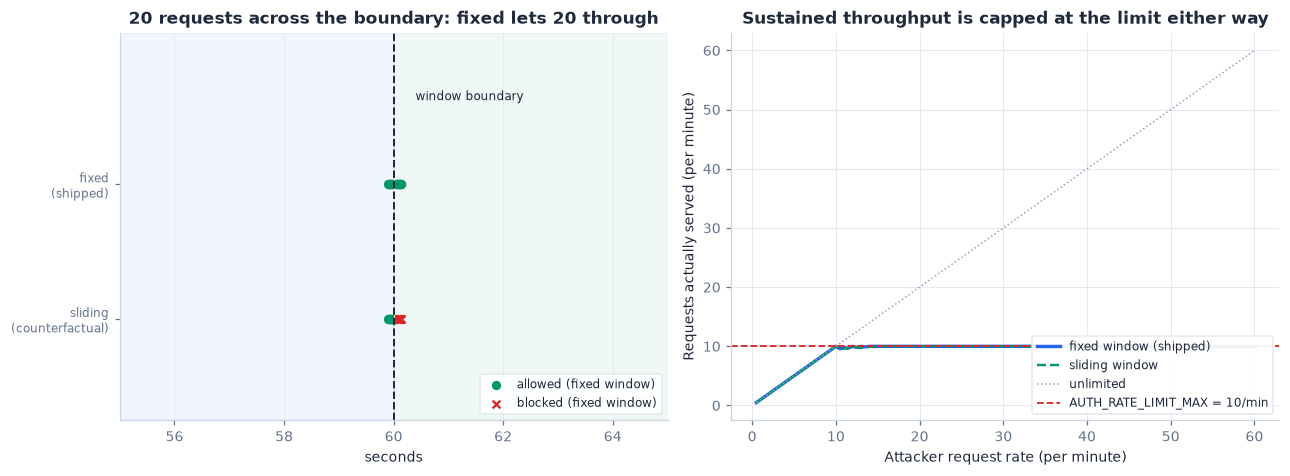


At 10 req/min an attacker gets 10/min through the KDF -> 2.0% of one core busy


In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.8, 4.4))

# (a) Boundary burst visualised.
ax1.axvspan(0, AUTH_WINDOW, color=BLUE, alpha=0.06)
ax1.axvspan(AUTH_WINDOW, 2 * AUTH_WINDOW, color=GREEN, alpha=0.06)
ax1.scatter(fa, [1] * len(fa), color=GREEN, s=26, label="allowed (fixed window)")
ax1.scatter(fb, [1] * len(fb), color=RED, s=26, marker="x", label="blocked (fixed window)")
ax1.scatter(sa, [0.6] * len(sa), color=GREEN, s=26)
ax1.scatter(sb, [0.6] * len(sb), color=RED, s=26, marker="x")
ax1.axvline(AUTH_WINDOW, color=INK, ls="--", lw=1.3)
ax1.text(AUTH_WINDOW + 0.4, 1.25, "window boundary", fontsize=8, color=INK)
ax1.set_yticks([0.6, 1.0]); ax1.set_yticklabels(["sliding\n(counterfactual)", "fixed\n(shipped)"], fontsize=8)
ax1.set_xlim(55, 65); ax1.set_ylim(0.3, 1.45)
ax1.set_xlabel("seconds")
ax1.set_title("%d requests across the boundary: fixed lets %d through" % (len(attack), len(fa)))
ax1.legend(fontsize=7.6, loc="lower right"); ax1.grid(True, axis="x")

# (b) Sustained attack: how much throughput does an attacker actually get?
rates = [r / 2 for r in range(1, 121)]      # requests per minute
fixed_through, sliding_through = [], []
for r in rates:
    gap = 60.0 / r
    arrivals = [i * gap for i in range(int(r * 10))]     # ten minutes
    fixed_through.append(len(fixed_window(arrivals)[0]) / 10.0)
    sliding_through.append(len(sliding_window(arrivals)[0]) / 10.0)
ax2.plot(rates, fixed_through, color=BLUE, lw=2.2, label="fixed window (shipped)")
ax2.plot(rates, sliding_through, color=GREEN, lw=1.6, ls="--", label="sliding window")
ax2.plot(rates, rates, color=GREY, lw=1.0, ls=":", label="unlimited")
ax2.axhline(AUTH_MAX, color=RED, ls="--", lw=1.2, label="AUTH_RATE_LIMIT_MAX = %d/min" % AUTH_MAX)
ax2.set_xlabel("Attacker request rate (per minute)")
ax2.set_ylabel("Requests actually served (per minute)")
ax2.set_title("Sustained throughput is capped at the limit either way")
ax2.grid(True); ax2.legend(fontsize=7.6, loc="lower right")

fig.tight_layout()
print("saved:", save(fig, "rate_limiting.png"))
plt.show()

print("\nAt %d req/min an attacker gets %d/min through the KDF -> %.1f%% of one core busy"
      % (AUTH_MAX, AUTH_MAX, AUTH_MAX * verify_ms / 60000 * 100))

## 5.3 OTP brute-force resistance

`otp_service` issues a **6-digit** code from `secrets.randbelow` (a CSPRNG — the comment in the
source is explicit that `random` is not uniform), stores an **Argon2id hash** of it, and enforces
three independent limits:

| Limit | Value | Where it lives | Survives a Redis outage? |
|---|---|---|---|
| Code lifetime | `OTP_TTL_SECONDS = 600` | row `expires_at` | yes |
| Wrong guesses | `OTP_MAX_ATTEMPTS = 5` | row `attempts`, same transaction | **yes — Postgres** |
| Sends per address | 5 per 900 s | Postgres count query | **yes — Postgres** |
| Sends per IP | 10 per 60 s | Redis (§5.2) | no — fails open |

The attempt counter deliberately lives in Postgres rather than Redis precisely because the Redis
limiter fails open. Also note the enumeration defence: `issue_otp` returns `None` for every input,
and a signup code for an existing address is quietly downgraded to a login code rather than
revealing that the address is taken.

code space              : 1000000 (6 digits, secrets.randbelow)
guesses per issued code : 5
P(break one code)       : 5.00e-06  (1 in 200000)
codes obtainable / hour : 20.0  (5 per 900s window, per address)
guesses / hour          : 100
expected hours to break : 10000  (~1.1 years of uninterrupted attack on ONE address)


saved: docs/assets/notebooks/otp_bruteforce.png


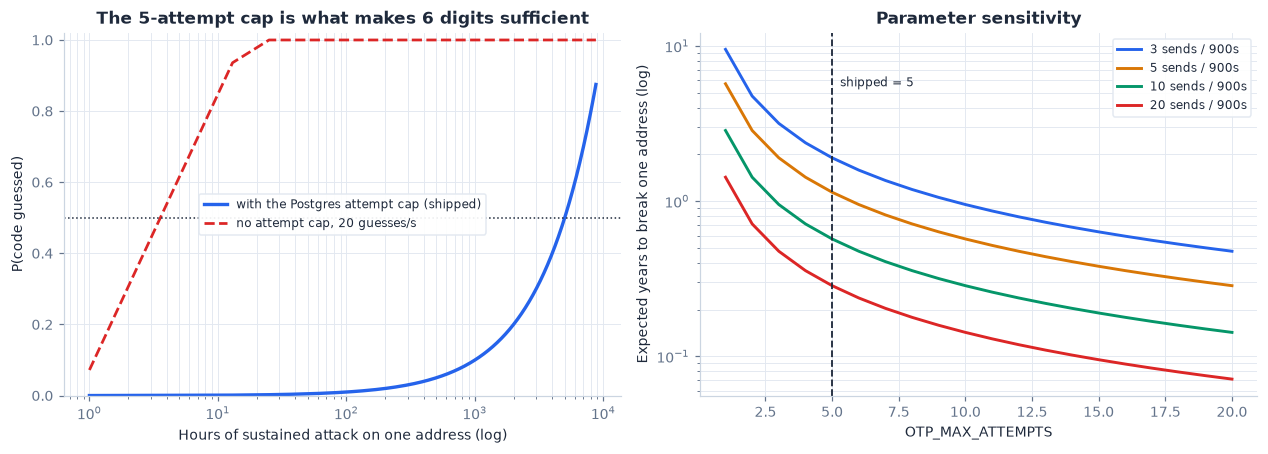

In [39]:
OTP_SPACE, OTP_MAX_ATTEMPTS, OTP_TTL, OTP_SENDS, OTP_SEND_WINDOW = 1_000_000, 5, 600, 5, 900

# P(at least one hit) with k guesses against a uniform 6-digit space, without replacement.
def p_success(guesses, space=OTP_SPACE):
    return 1.0 - math.prod((space - i - 1) / (space - i) for i in range(min(guesses, space - 1)))

per_code = p_success(OTP_MAX_ATTEMPTS)
codes_per_hour = OTP_SENDS * 3600 / OTP_SEND_WINDOW
guesses_per_hour = codes_per_hour * OTP_MAX_ATTEMPTS

print("code space              : %d (6 digits, secrets.randbelow)" % OTP_SPACE)
print("guesses per issued code : %d" % OTP_MAX_ATTEMPTS)
print("P(break one code)       : %.2e  (1 in %.0f)" % (per_code, 1 / per_code))
print("codes obtainable / hour : %.1f  (%d per %ds window, per address)"
      % (codes_per_hour, OTP_SENDS, OTP_SEND_WINDOW))
print("guesses / hour          : %.0f" % guesses_per_hour)
print("expected hours to break : %.0f  (~%.1f years of uninterrupted attack on ONE address)"
      % (OTP_SPACE / guesses_per_hour, OTP_SPACE / guesses_per_hour / 8766))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.2))

hours = list(range(1, 24 * 365 + 1, 12))
ax1.plot(hours, [p_success(int(h * guesses_per_hour)) for h in hours], color=BLUE, lw=2.2,
         label="with the Postgres attempt cap (shipped)")
ax1.plot(hours, [p_success(int(h * 3600 * 20)) for h in hours], color=RED, lw=1.8, ls="--",
         label="no attempt cap, 20 guesses/s")
ax1.set_xscale("log")
ax1.axhline(0.5, color=INK, ls=":", lw=1.0)
ax1.set_xlabel("Hours of sustained attack on one address (log)")
ax1.set_ylabel("P(code guessed)")
ax1.set_title("The 5-attempt cap is what makes 6 digits sufficient")
ax1.set_ylim(0, 1.02); ax1.grid(True, which="both"); ax1.legend(fontsize=7.6)

# Sensitivity to the two tunable parameters.
attempt_axis = list(range(1, 21))
for colour, sends in zip(SERIES, [3, 5, 10, 20]):
    gph = sends * 3600 / OTP_SEND_WINDOW
    ax2.plot(attempt_axis, [OTP_SPACE / (gph * a) / 8766 for a in attempt_axis],
             color=colour, lw=1.9, label="%d sends / %ds" % (sends, OTP_SEND_WINDOW))
ax2.axvline(OTP_MAX_ATTEMPTS, color=INK, ls="--", lw=1.2)
ax2.text(OTP_MAX_ATTEMPTS + 0.3, ax2.get_ylim()[1] * 0.55, "shipped = %d" % OTP_MAX_ATTEMPTS,
         fontsize=8, color=INK)
ax2.set_yscale("log")
ax2.set_xlabel("OTP_MAX_ATTEMPTS"); ax2.set_ylabel("Expected years to break one address (log)")
ax2.set_title("Parameter sensitivity")
ax2.grid(True, which="both"); ax2.legend(fontsize=7.6)

fig.tight_layout()
print("saved:", save(fig, "otp_bruteforce.png"))
plt.show()

## 5.4 PII retention schedule

**The problem.** Affiliate click attribution needs an IP address and user agent. Keeping them
forever is a liability with no product benefit.

**The decision** (`services/pii.py`, applied in bulk by `retention_service.run_retention_sweep`):
deadlines are precomputed on session insert, so the sweep is three `UPDATE` statements rather
than per-row Python.

| Age | Action |
|---|---|
| >= 30 days | raw IP replaced by a salted SHA-256 hash (`{salt}:{ip}`) |
| >= 90 days | the hash itself deleted |
| >= 90 days | user agent purged |

The Postgres sweep hashes with `encode(sha256(convert_to(:salt || ':' || host(ip_address),
'UTF8')), 'hex')` — byte-identical to `pii.hash_ip`, so the two paths are interchangeable.

def due_actions(
    *,
    clicked_at: datetime,
    now: datetime,
    has_user_agent: bool,
    has_raw_ip: bool,
    has_ip_hash: bool,
) -> set[str]:
    """Return the retention actions currently due for one session.

    Actions: "hash_ip" (>=30d, raw IP still present), "delete_ip_hash" (>=90d),
    "purge_ua" (>=90d, UA still present).
    """
    deadlines = retention_deadlines(clicked_at)
    actions: set[str] = set()
    if has_raw_ip and now >= deadlines["ip_hash_at"]:
        actions.add("hash_ip")
    if now >= deadlines["ip_delete_at"] and (has_ip_hash or has_raw_ip):
        actions.add("delete_ip_hash")
    if has_user_agent and now >= deadlines["ua_purge_at"]:
        actions.add("purge_ua")
    return actions

  ip_hash_at     2026-01-31
  ip_delete_at   2026-04-01
  ua_purge_at    2026-04-01

Salted hash is deterministic and irreversible:
  hash_ip('203.0.113.7', 'pepper') = e0dc27fa1b25a23ba014e36d2a1f1f84 ...
  same input twice identical?      : True
  different sa

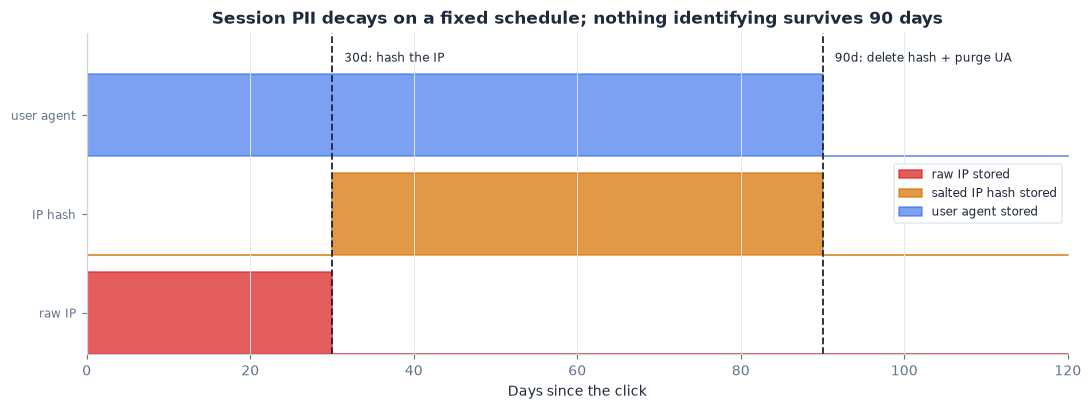


Transitions:
  day  30 -> hash_ip
  day  90 -> delete_ip_hash, purge_ua


In [40]:
from datetime import UTC, datetime, timedelta

print(inspect.getsource(due_actions))

clicked = datetime(2026, 1, 1, tzinfo=UTC)
deadlines = retention_deadlines(clicked)
for k, v in deadlines.items():
    print("  %-14s %s" % (k, v.date()))

print("\nSalted hash is deterministic and irreversible:")
print("  hash_ip('203.0.113.7', 'pepper') =", hash_ip("203.0.113.7", "pepper")[:32], "...")
print("  same input twice identical?      :",
      hash_ip("203.0.113.7", "pepper") == hash_ip("203.0.113.7", "pepper"))
print("  different salt -> different hash :",
      hash_ip("203.0.113.7", "pepper") != hash_ip("203.0.113.7", "salt2"))

# Walk one session through its full lifecycle.
state = {"has_raw_ip": True, "has_ip_hash": False, "has_user_agent": True}
rows = []
for day in range(0, 121):
    now = clicked + timedelta(days=day)
    actions = due_actions(clicked_at=clicked, now=now, **state)
    if "hash_ip" in actions:
        state["has_raw_ip"], state["has_ip_hash"] = False, True
    if "delete_ip_hash" in actions:
        state["has_raw_ip"], state["has_ip_hash"] = False, False
    if "purge_ua" in actions:
        state["has_user_agent"] = False
    rows.append((day, int(state["has_raw_ip"]), int(state["has_ip_hash"]),
                 int(state["has_user_agent"]), sorted(actions)))

fig, ax = plt.subplots(figsize=(10.0, 3.8))
days = [r[0] for r in rows]
ax.fill_between(days, 0, [r[1] for r in rows], step="post", color=RED, alpha=0.75, label="raw IP stored")
ax.fill_between(days, 1.2, [1.2 + r[2] for r in rows], step="post", color=AMBER, alpha=0.75,
                label="salted IP hash stored")
ax.fill_between(days, 2.4, [2.4 + r[3] for r in rows], step="post", color=BLUE, alpha=0.6,
                label="user agent stored")
for d, colour, lbl in [(30, INK, "30d: hash the IP"), (90, INK, "90d: delete hash + purge UA")]:
    ax.axvline(d, color=colour, ls="--", lw=1.2)
    ax.text(d + 1.5, 3.55, lbl, fontsize=8, color=INK)
ax.set_yticks([0.5, 1.7, 2.9]); ax.set_yticklabels(["raw IP", "IP hash", "user agent"], fontsize=8)
ax.set_xlabel("Days since the click"); ax.set_xlim(0, 120); ax.set_ylim(0, 3.9)
ax.set_title("Session PII decays on a fixed schedule; nothing identifying survives 90 days")
ax.legend(fontsize=7.6, loc="center right"); ax.grid(True, axis="x")
fig.tight_layout()
print("\nsaved:", save(fig, "pii_retention.png"))
plt.show()

print("\nTransitions:")
for day, raw, h, ua, actions in rows:
    if actions:
        print("  day %3d -> %s" % (day, ", ".join(actions)))

---
# Part 6 — Content heuristics

## 6.1 AI critique — the deterministic stub (ADR-013)

**The problem.** M1 required "basic AI critique integration". Making a network call to a paid API
a hard dependency means the system cannot be run, tested, or demonstrated without a key.

**The decision.** A provider abstraction (`stub` | `claude` | `openai`) selected by `AI_PROVIDER`.
The **default is `stub`**: a deterministic heuristic with no network and no key, so the platform
runs and is testable out of the box, and swapping to a real model is an environment change rather
than a code change.

The stub's scoring rule (`StubProvider.critique`):

$$
\mathrm{score} = \min\Big(100,\; 30 + \min\big(40, \lfloor wc/5 \rfloor\big) + 15\,[\text{pros}] + 15\,[\text{cons}]\Big)
$$

where `pros` is any of `pro / good / like / love` and `cons` any of `con / bad / issue / but /
however` appearing as a substring of the lower-cased draft. It is simulated here because it is
what actually runs by default — and because its substring matching is worth being honest about.

In [41]:
print(inspect.getsource(StubProvider.critique))
stub = StubProvider()

samples = [
    ("empty-ish", "Good."),
    ("short, positive only", "I love this. It works well and I like the design a lot."),
    ("long, positive only", " ".join(["The build quality is good and I love the finish."] * 12)),
    ("balanced, short", "Good battery but the strap is bad."),
    ("balanced, long", " ".join(["Good battery life, though the strap has an issue."] * 12)),
    ("false positive", "The delivery was late, however the product itself is a problem."),
]
print("%-24s %5s %6s %6s %7s" % ("draft", "words", "pros?", "cons?", "score"))
for label, text in samples:
    r = stub.critique(None, text)
    low = text.lower()
    print("%-24s %5d %6s %6s %7d"
          % (label, len(text.split()),
             any(w in low for w in ("pro", "good", "like", "love")),
             any(w in low for w in ("con", "bad", "issue", "but", "however")),
             r.quality_score))

    def critique(self, title: str | None, text: str) -> CritiqueResponse:
        words = text.split()
        wc = len(words)
        has_pros = any(w in text.lower() for w in ("pro", "good", "like", "love"))
        has_cons = any(w in text.lower() for w in ("con", "bad", "issue", "but", "however"))
        score = min(100, 30 + min(40, wc // 5) + (15 if has_pros else 0) + (15 if has_cons else 0))
        strengths, weaknesses, suggestions = [], [], []
        (strengths if wc >= 40 else weaknesses).append(
            "Sufficient detail." if wc >= 40 else "Very short — add specifics.")
        (strengths if has_pros and has_cons else weaknesses).append(
            "Balanced pros and cons." if has_pros and has_cons
            else "Mention both upsides and downsides.")
        if not has_cons:
            suggestions.append("Add at least one honest drawback.")
        suggestions.append("Include what you used it for and for how long.")
        return CritiqueResponse(
            p

saved: docs/assets/notebooks/ai_critique_stub.png


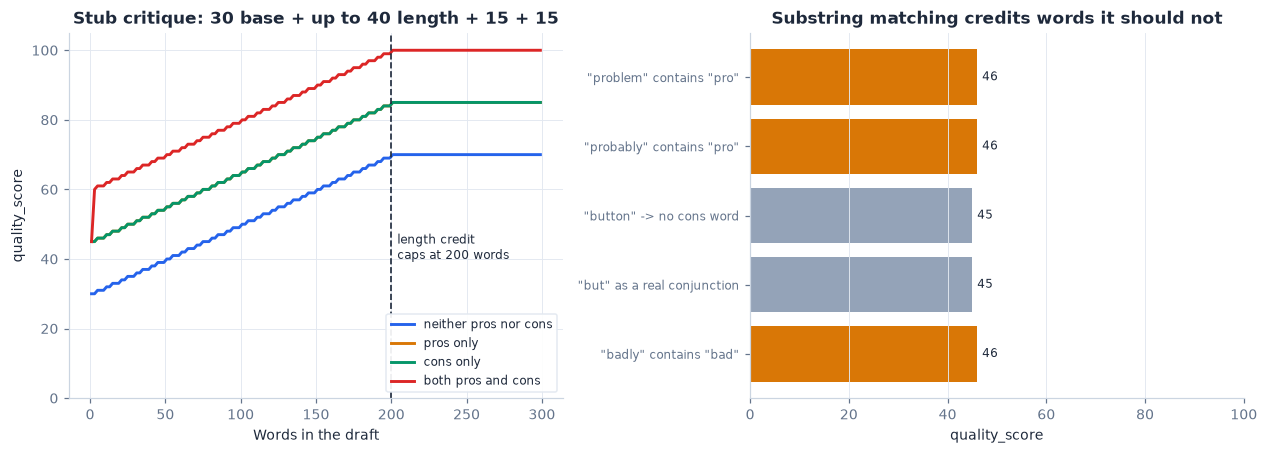

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.2))

# (a) Score surface over word count x pros/cons presence.
wc_axis = list(range(1, 301, 2))
variants = [("neither pros nor cons", "widget " ), ("pros only", "good widget "),
            ("cons only", "bad widget "), ("both pros and cons", "good but bad widget ")]
for colour, (label, unit) in zip(SERIES, variants):
    ys = []
    for wc in wc_axis:
        text = (unit * (wc // len(unit.split()) + 1))
        text = " ".join(text.split()[:wc])
        ys.append(stub.critique(None, text).quality_score)
    ax1.plot(wc_axis, ys, color=colour, lw=1.9, label=label)
ax1.axvline(200, color=INK, ls="--", lw=1.1)
ax1.text(204, 40, "length credit\ncaps at 200 words", fontsize=7.8, color=INK)
ax1.set_xlabel("Words in the draft"); ax1.set_ylabel("quality_score")
ax1.set_title("Stub critique: 30 base + up to 40 length + 15 + 15")
ax1.set_ylim(0, 105); ax1.grid(True); ax1.legend(fontsize=7.6, loc="lower right")

# (b) The substring problem, demonstrated.
traps = [
    ('"problem" contains "pro"', "This has a problem with the battery."),
    ('"probably" contains "pro"', "It will probably last a year."),
    ('"button" -> no cons word', "The button feels cheap."),
    ('"but" as a real conjunction', "Fast but noisy."),
    ('"badly" contains "bad"', "It is badly needed by everyone."),
]
labels = [t[0] for t in traps]
scores = [stub.critique(None, t[1]).quality_score for t in traps]
ax2.barh(range(len(traps)), scores, color=[AMBER if "contains" in l else GREY for l in labels])
ax2.set_yticks(range(len(traps))); ax2.set_yticklabels(labels, fontsize=7.8)
ax2.invert_yaxis()
for i, s in enumerate(scores):
    ax2.text(s + 1, i, str(s), va="center", fontsize=8, color=INK)
ax2.set_xlabel("quality_score"); ax2.set_xlim(0, 100)
ax2.set_title("Substring matching credits words it should not")
ax2.grid(True, axis="x")

fig.tight_layout()
print("saved:", save(fig, "ai_critique_stub.png"))
plt.show()

**What this means for the product.** The stub is an *availability* decision, not a quality claim.
Its heuristic is legible, deterministic and cheap — and demonstrably credits "problem" as a pro
because it contains `pro`. That is acceptable for a fallback whose output is advisory writing
guidance shown to an author, and unacceptable as a moderation input; the codebase never uses the
critique score for any gating decision. In production `AI_PROVIDER=claude` replaces the heuristic
entirely.

## 6.2 Request screening — `heuristic_validate`

The same module screens "please review this product" requests before they reach the board. Three
deterministic rejection rules, pinned as the contract the tests assert:

1. details shorter than `MIN_DETAILS_CHARS` (30)
2. details that merely repeat the title (case-insensitive)
3. a URL in the body whose host differs from `source_url`'s host — a common spam shape

In [43]:
print("MIN_DETAILS_CHARS =", ai_critique.MIN_DETAILS_CHARS)
cases = [
    ("too short", "Bag", "Is it good?", None),
    ("repeats title", "Anker 737 power bank",
     "Anker 737 power bank", None),
    ("foreign link", "Anker 737 power bank",
     "Please check whether the 140W output actually holds under load. https://spam.example/x",
     "https://shopee.ph/anker-737"),
    ("same-host link", "Anker 737 power bank",
     "Please check whether the 140W output actually holds under load. https://shopee.ph/anker-737",
     "https://shopee.ph/anker-737"),
    ("clean request", "Anker 737 power bank",
     "Does the 140W output hold under sustained load, and how hot does it get?",
     "https://shopee.ph/anker-737"),
]
for label, title, details, src in cases:
    valid, reasons = heuristic_validate(title, details, src)
    print("%-16s valid=%-5s %s" % (label, valid, reasons or ""))

MIN_DETAILS_CHARS = 30
too short        valid=False ['Details must be at least 30 characters so a reviewer knows what to evaluate.']
repeats title    valid=False ['Details must be at least 30 characters so a reviewer knows what to evaluate.', 'Details merely repeat the title.']
foreign link     valid=False ['Details contain an unrelated link (spam.example); put the product link in source_url instead.']
same-host link   valid=True  
clean request    valid=True  


## 6.3 Duplicate-content detection — trigram similarity

**The problem.** Copy-pasted reviews (across products, or by the same author) are a classic shill
pattern.

**The decision** (`fraud_service._duplicate_content`): a PostgreSQL `pg_trgm` similarity query
against other reviews of the same product *or* by the same author, thresholded at
`DUPLICATE_SIMILARITY_THRESHOLD = 0.85`. Advisory only, computed on read for the moderator queue.

The production computation happens **inside Postgres**, so the cell below is a faithful Python
port of pg_trgm's algorithm — words padded with two leading and one trailing space, 3-grams
extracted, similarity = |A ∩ B| / |A ∪ B| — used to characterise the threshold. It is labelled as
a port rather than presented as the shipped code.

In [44]:
import re as _re

def _trigrams(text: str) -> set[str]:
    # Faithful port of pg_trgm: lowercase, split on non-alphanumerics, pad '  word ', 3-grams.
    words = [w for w in _re.split(r"[^A-Za-z0-9]+", text.lower()) if w]
    grams = set()
    for w in words:
        padded = "  " + w + " "
        for i in range(len(padded) - 2):
            grams.add(padded[i:i + 3])
    return grams


def trgm_similarity(a: str, b: str) -> float:
    ga, gb = _trigrams(a), _trigrams(b)
    if not ga and not gb:
        return 0.0
    return len(ga & gb) / len(ga | gb)


THRESHOLD = 0.85       # settings.duplicate_similarity_threshold

BASE = ("Battery lasts about two days with heavy use and the charging brick stays cool. "
        "The strap started fraying after three weeks which is disappointing at this price.")
VARIANTS = [
    ("identical", BASE),
    ("whitespace only", BASE.replace(" ", "  ")),
    ("one word swapped", BASE.replace("disappointing", "frustrating")),
    ("punctuation added", BASE.replace(".", "!")),
    ("one sentence dropped", BASE.split(". ")[0]),
    ("reordered sentences", ". ".join(reversed(BASE.split(". ")))),
    ("paraphrased", "Two days of battery under heavy load, charger stays cool. "
                    "Strap frayed within a month, poor for the money."),
    ("unrelated review", "Arrived in three days, packaging was crushed but the item was fine. "
                         "Colour matches the listing photos exactly."),
]
print("%-24s %10s %10s" % ("variant", "similarity", "flagged"))
sims = []
for label, text in VARIANTS:
    s = trgm_similarity(BASE, text)
    sims.append((label, s))
    print("%-24s %10.4f %10s" % (label, s, s > THRESHOLD))

variant                  similarity    flagged
identical                    1.0000       True
whitespace only              1.0000       True
one word swapped             0.8872       True
punctuation added            1.0000       True
one sentence dropped         0.5625      False
reordered sentences          1.0000       True
paraphrased                  0.3688      False
unrelated review             0.1458      False


saved: docs/assets/notebooks/duplicate_content.png


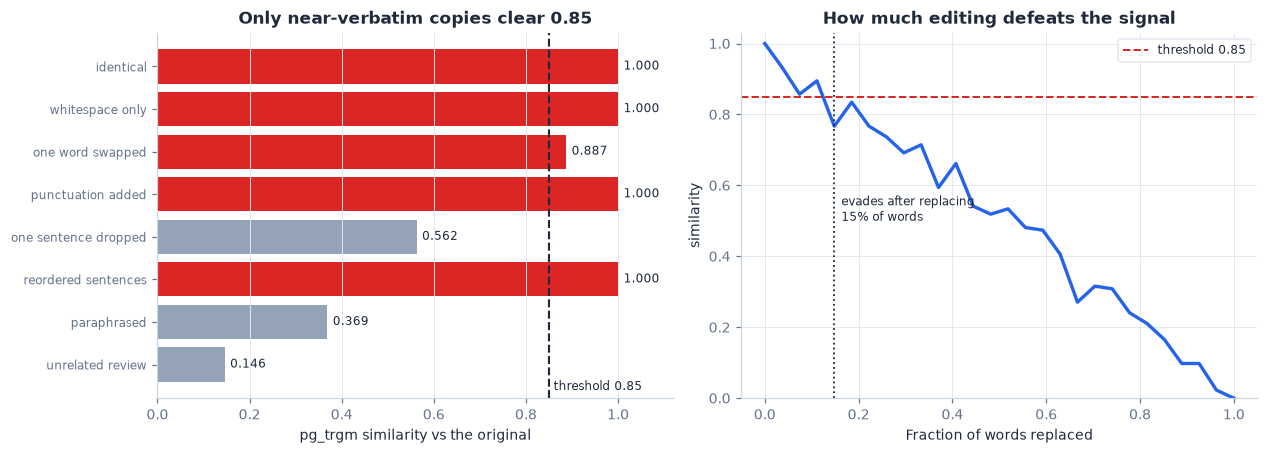


Evasion point: replacing ~15% of words drops below the 0.85 threshold.


In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.2))

labels = [s[0] for s in sims]
vals = [s[1] for s in sims]
ax1.barh(range(len(sims)), vals, color=[RED if v > THRESHOLD else GREY for v in vals])
ax1.axvline(THRESHOLD, color=INK, ls="--", lw=1.4)
ax1.text(THRESHOLD + 0.01, len(sims) - 0.4, "threshold %.2f" % THRESHOLD, fontsize=8, color=INK)
ax1.set_yticks(range(len(sims))); ax1.set_yticklabels(labels, fontsize=8)
ax1.invert_yaxis()
for i, v in enumerate(vals):
    ax1.text(v + 0.012, i, "%.3f" % v, va="center", fontsize=7.8, color=INK)
ax1.set_xlim(0, 1.12); ax1.set_xlabel("pg_trgm similarity vs the original")
ax1.set_title("Only near-verbatim copies clear 0.85")
ax1.grid(True, axis="x")

# Threshold sensitivity: progressive word substitution.
words = BASE.split()
frac_axis, sim_axis = [], []
rng2 = random.Random(5)
for k in range(0, len(words) + 1):
    idx = set(rng2.sample(range(len(words)), k)) if k else set()
    mutated = " ".join("zzqx" if i in idx else w for i, w in enumerate(words))
    frac_axis.append(k / len(words))
    sim_axis.append(trgm_similarity(BASE, mutated))
ax2.plot(frac_axis, sim_axis, color=BLUE, lw=2.2)
ax2.axhline(THRESHOLD, color=RED, ls="--", lw=1.3, label="threshold %.2f" % THRESHOLD)
cross = next((f for f, s in zip(frac_axis, sim_axis) if s <= THRESHOLD), None)
if cross is not None:
    ax2.axvline(cross, color=INK, ls=":", lw=1.2)
    ax2.text(cross + 0.015, 0.5, "evades after replacing\n%.0f%% of words" % (cross * 100),
             fontsize=8, color=INK)
ax2.set_xlabel("Fraction of words replaced"); ax2.set_ylabel("similarity")
ax2.set_title("How much editing defeats the signal")
ax2.set_ylim(0, 1.03); ax2.grid(True); ax2.legend(fontsize=8)

fig.tight_layout()
print("saved:", save(fig, "duplicate_content.png"))
plt.show()
print("\nEvasion point: replacing ~%.0f%% of words drops below the 0.85 threshold."
      % ((cross or 0) * 100))

**What this means for the product.** At 0.85 the signal catches copy-paste and near-copy-paste and
nothing else — swapping roughly one word in twenty already evades it. Combined with the fact that
it is advisory and queue-only, this is a *convenience* for moderators reviewing an obvious
duplicate, not an anti-plagiarism system. The genuinely strong signal in this area (photo pHash
reverse-image matching) is documented as deferred in `fraud_service`'s module docstring.

## 6.4 Username slugification and collision-safe allocation

`slugify_username` NFKD-normalises, strips to ASCII, lower-cases, collapses runs of invalid
characters to a single `_`, trims leading/trailing `_`, and truncates to 32 characters. The same
rules are mirrored in SQL by migration 0016 so the backfill and the runtime cannot disagree.

`allocate_username` then tries, in order: the preferred handle, the email local-part, and
`user_<8 hex>` — appending numeric suffixes 2..999 on collision, **trimming the base so the
suffixed handle still fits 32 characters**, with a UUID-based final fallback that cannot collide.

In [46]:
print(inspect.getsource(slugify_username))
for raw in ["Maria Clara", "  José  Rizal  ", "Ünïcödé Nâme", "!!!", "a", "user@@name",
            "A very long display name that will certainly exceed the thirty-two character limit",
            "___leading_and_trailing___"]:
    slug = slugify_username(raw)
    print("  %-78s -> %-34s len=%2d valid=%s"
          % (repr(raw), repr(slug), len(slug), is_valid_username(slug)))

def slugify_username(raw: str) -> str:
    """Lowercase, ASCII-fold, collapse invalid runs to `_`, trim to 32."""
    folded = unicodedata.normalize("NFKD", raw)
    folded = folded.encode("ascii", "ignore").decode("ascii")
    slug = re.sub(r"[^a-z0-9]+", "_", folded.lower())
    slug = re.sub(r"_{2,}", "_", slug).strip("_")
    return slug[:MAX_LENGTH]

  'Maria Clara'                                                                  -> 'maria_clara'                      len=11 valid=True
  '  José  Rizal  '                                                              -> 'jose_rizal'                       len=10 valid=True
  'Ünïcödé Nâme'                                                                 -> 'unicode_name'                     len=12 valid=True
  '!!!'                                                                          -> ''                                 len= 0 valid=False
  'a'                                                                            -> 'a'      

In [47]:
# Collision behaviour, simulating the DB-uniqueness check in allocate_username.
def allocate_offline(taken: set[str], base: str) -> str:
    # Mirror of allocate_username's suffix loop (username.py:53-64).
    if len(base) < username.MIN_LENGTH:
        return None
    if base not in taken:
        return base
    for suffix in range(2, 1000):
        trimmed = base[: username.MAX_LENGTH - len(str(suffix))]
        candidate = "%s%d" % (trimmed, suffix)
        if candidate not in taken:
            return candidate
    return None


taken = set()
issued = []
for _ in range(120):
    handle = allocate_offline(taken, "maria")
    taken.add(handle); issued.append(handle)
print("first 8 :", issued[:8])
print("last 4  :", issued[-4:])
print("all unique:", len(set(issued)) == len(issued))

long_base = slugify_username("a" * 40)
taken2 = set()
lengths = []
for _ in range(500):
    h = allocate_offline(taken2, long_base)
    taken2.add(h); lengths.append(len(h))
print("\nlong base (%d chars) suffixed 500 times -> max handle length %d (limit %d)"
      % (len(long_base), max(lengths), username.MAX_LENGTH))
assert max(lengths) <= username.MAX_LENGTH
print("length invariant holds: no allocated handle exceeds MAX_LENGTH")

first 8 : ['maria', 'maria2', 'maria3', 'maria4', 'maria5', 'maria6', 'maria7', 'maria8']
last 4  : ['maria117', 'maria118', 'maria119', 'maria120']
all unique: True

long base (32 chars) suffixed 500 times -> max handle length 32 (limit 32)
length invariant holds: no allocated handle exceeds MAX_LENGTH


---
# Part 7 — Coverage ledger

Stated plainly, because a defense panel is entitled to know the edges of the claim.

## Covered above, with a runnable simulation and a chart

| # | Algorithm | Source | Wired in a request path? |
|---|---|---|---|
| 1 | Wilson score lower bound | `ranking.py` | yes — `reviews.wilson_score`, feed ordering |
| 2 | Exponential recency decay | `ranking.py` | yes — via time-decayed Wilson |
| 3 | Time-decayed Wilson | `ranking.py` | yes — vote writes + nightly sweep |
| 4 | Velocity (surge) detection | `ranking.py` / `fraud_service.py` | yes — moderator queue, advisory |
| 5 | Review-level collusion | `fraud_service.py` | yes — moderator queue, advisory |
| 6 | Pairwise reciprocity | `ranking.py` | **no** — pure function, tests only |
| 7 | Publication gate | `ranking.py` | **no** — publication is moderator-driven |
| 8 | Seeding phase transition | `ranking.py` | **no** |
| 9 | Reputation score | `trust.py` | yes — `trust_service.recompute_user_trust` |
| 10 | Trust-stage ladder | `trust.py` | yes — same recompute; badges awarded on rise |
| 11 | Gate vote weight | `trust.py` | yes — Honesty Fund distribution |
| 12 | Product trust rating | `trust_rating_service.py` | yes — publish/edit + nightly |
| 13 | Low-trust visibility threshold | `trust_rating_service.py` | config-driven, ships **off** |
| 14 | 40/30/30 commission split | `earnings.py` | yes — CSV reconciliation |
| 15 | Tiered commission split | `earnings.py` | yes — reads `membership_tiers` |
| 16 | Contract gate on reviewer bps | `contract_service.py` | yes — at reconciliation |
| 17 | Honesty Score + distribution | `trust.py` / `honesty_fund_service.py` | yes — monthly cycle |
| 18 | Honesty price multiplier | `constants.py` | yes |
| 19 | Payout tier priority + reservation | `payout_service.py` | yes |
| 20 | Argon2id KDF | `core/security.py` | yes — measured on this machine |
| 21 | Fixed-window rate limiting | `core/rate_limit.py` | yes — auth-adjacent endpoints |
| 22 | OTP brute-force resistance | `otp_service.py` | yes |
| 23 | PII retention schedule | `pii.py` / `retention_service.py` | yes — nightly sweep |
| 24 | AI critique stub heuristic | `ai_critique.py` | yes — default provider |
| 25 | Request screening heuristic | `ai_critique.py` | yes |
| 26 | Duplicate-content similarity | `fraud_service.py` | yes — moderator queue, advisory |
| 27 | Username slugify + allocation | `username.py` | yes — signup |

## Present in the codebase but NOT simulated here, and why

| Algorithm | Source | Why not |
|---|---|---|
| `pg_trgm` similarity as executed | `fraud_service._duplicate_content` | Runs as SQL inside PostgreSQL. §6.3 uses a faithful Python port of the same algorithm and says so; simulating the real path needs a live database with the `pg_trgm` extension, which this notebook deliberately does not require. |
| Commission CSV matching cascade | `commission_service.import_commissions` | Ingestion and idempotency logic (sub-ID -> click_ref -> order_ref, `(csv_source, row_reference)` de-duplication), not a numeric algorithm. Its one piece of arithmetic — the split — is §4.1. |
| Marketplace report adapters | `report_formats.py` | Format normalisation for real Shopee/Lazada exports; parsing, not mathematics. |
| Token ledger | `token_service.grant` | Signed integer addition with a row lock and a partial unique index. The interesting property is transactional (savepoint + idempotency), not computational; simulating it without a database would prove nothing. |
| PayPal batch settlement | `payout_service` + `adapters/paypal` | External provider state machine. The wallet invariant it must preserve is simulated in §4.4. |
| JWT mint/verify | `core/security.py` | Standard HS256 via PyJWT; measured as a latency component in §5.1 but not otherwise novel. |
| Contract auto-renew sweep | `contract_service.sweep_contracts` | Calendar arithmetic via `relativedelta`; its economic effect (the bps gate) is §4.2. |
| Best Answer / First Responder | `qa_service.py` | Flag assignment and badge award, no scoring formula. |
| **Seller trust ratings** | — (deleted) | **Removed from the codebase** by owner decision (commits `cf7afbc` / `8936dda`): `seller_reviews`, `recompute_seller_trust` and the `/sellers` endpoints no longer exist, so there is nothing to simulate. *Product* trust is a different, surviving feature — Part 3. |

## Findings this notebook records

1. **F1 — a brigade outruns moderation.** 200 up-votes in 10 minutes reach the homepage top-6 in
   about a minute. The velocity flag fires but is advisory; nothing is auto-blocked (FR-8).
2. **F2 — down-votes are invisible to the velocity signal.** `fraud_service._velocity_flag`
   filters to up-votes only, so a 150-vote raid that pushes a healthy review below the
   earn-eligible gate produces no signal.
3. **F3 — three ranking functions are unwired.** `reciprocity_flag`, `gate_passes` and
   `is_post_seeding` are tested but have no caller in `app/`; publication and monetisation are
   moderator-driven today.
4. **F4 — small collusion rings are structurally invisible.** `|V| >= 5` means a four-account ring
   can never be flagged.
5. **F5 — the Honesty Fund price bracket is a cliff.** PHP 499 -> 1.0x, PHP 500 -> 1.5x.
6. **F6 — Stage 4 is the only stage that requires zero strikes.** A user with strikes can still
   reach Stage 5 on volume, helpfulness and tenure.
7. **F7 — product trust discards the difference between 3-star and 1-star.** Two products with
   averages a full star apart can carry the same `trust_score`.
8. **F8 — fixed-window rate limiting permits close to 2x the nominal rate at the window boundary**
   (measured in §5.2), and fails open when Redis is
   down. The OTP attempt cap in Postgres is the compensating control.
9. **F9 — the AI critique stub credits substrings**, e.g. "problem" satisfies the `pro` test. Its
   score gates nothing.

In [48]:
print("Notebook executed end to end.")
print("Figures written to:", ASSETS.relative_to(REPO).as_posix())
for p in sorted(ASSETS.glob("*.png")):
    print("  %-34s %6.1f KB" % (p.name, p.stat().st_size / 1024))

Notebook executed end to end.
Figures written to: docs/assets/notebooks
  ai_critique_stub.png                 62.6 KB
  argon2id.png                         57.3 KB
  commission_split.png                 70.7 KB
  contract_gate.png                    34.6 KB
  duplicate_content.png                69.7 KB
  gate_vote_weight.png                101.2 KB
  honesty_fund.png                     64.2 KB
  honesty_fund_weighting.png           65.6 KB
  otp_bruteforce.png                  102.6 KB
  payout_lifecycle.png                 59.6 KB
  pii_retention.png                    31.2 KB
  product_trust.png                    90.9 KB
  publication_gate.png                 61.7 KB
  rate_limiting.png                    64.2 KB
  recency_decay.png                   114.5 KB
  reciprocity_collusion.png            52.7 KB
  reputation_score.png                123.7 KB
  sim_scenarios_recap.png             126.6 KB
  time_decayed_wilson.png              80.3 KB
  trust_stage_ladder.png           